# Meta-Analysis of RAG Output

## Libraries Imported

In [3]:
import pandas as pd
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Import and Transformation

### Data Import

In [4]:
# load the responses from the JSON file
with open('./latest_output.json', 'r') as f:
    responses = json.load(f)


### Structuring the JSON File

In [5]:
def parse_q_string(q_string):
    parts = {}
    for field in ["QuestionText", "ShortAnswer", "Reasoning", "Evidence"]:
        # Match the value starting at the label and ending at the next label or end of string
        pattern = rf"{field}:\s*(.*?)(?=(QuestionText:|ShortAnswer:|Reasoning:|Evidence:|$))"
        match = re.search(pattern, q_string, re.DOTALL)
        if match:
            parts[field] = match.group(1).strip().rstrip(",")  # remove trailing comma if any
        else:
            parts[field] = 'Unfilled'
    return parts

In [6]:
for key in responses.keys():
    for question, answer in responses[key]['answers'].items():
        if type(answer) == str:
            responses[key]['answers'][question] = parse_q_string(answer)

In [7]:
for key in responses.keys():
    for question, answer in responses[key]['answers'].items():
        if type(answer) == str:
            responses = parse_q_string(answer)
            print("k:")
            print(k)
            print(f"id: {key} and title {responses[key]['metadata']['Title']}")
            break

### Flattening JSON File

In [8]:
def flattenDict(d, parent_key='', sep='-'):
    """
    Flattens a nested dictionary.

    Args:
        d (dict): The nested dictionary to flatten.
        parent_key (str): The parent key to use for the flattened dictionary.
        sep (str): The separator to use for the flattened dictionary.

    Returns:
        dict: The flattened dictionary.
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flattenDict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

def flattenJson(json):
    """
    Flattens a response json.

    Args:
        json (dict): The response json to flatten.

    Returns:
        dict: The flattened response json.
    """
    newJson={}
    for k,v in json.items():
        newJson[k]={}
        for k2,v2 in v.items():
            if isinstance(v2,dict):
                newJson[k].update(flattenDict(v2))
            else:
                newJson[k][k2]=v2
    return newJson

In [9]:
flat_responses=flattenJson(responses)
flat_responses['1']

{'paper_id': '1',
 'Title': '{ASM} in Action: Fast and Practical Learned Cardinality Estimation',
 'Authors': 'Sangoh Lee and\nKyoungmin Kim and\nWook{-}Shin Han',
 'Abstract': '',
 'Published Year': '2024',
 'Journal': '',
 'DOI': '10.1145/3626246.3654728',
 'Key': 'Lee2024ASM',
 'pdf_filename': 'ASM in Action Fast and Practical Learned Cardinality Estimation.pdf',
 'Volume': '',
 'Issue': '',
 'Pages': '',
 'Study': '',
 'Tags': '',
 'Notes': '',
 'Summary': '',
 'Category1': '',
 'Category2': '',
 'Owner': 'Amin',
 'Owner2': '',
 'Q1-QuestionText': 'Does the paper introduce a new definition of robustness?',
 'Q1-ShortAnswer': 'Unsure',
 'Q1-Reasoning': "The term 'robustness' is not mentioned in the provided context of the paper.",
 'Q1-Evidence': 'Not Applicable',
 'Q2-QuestionText': 'Does the paper define robustness or risk, either explicitly or implicitly? If yes, what is the definition? (Short answers: concise definition(s), Not provided, Unsure)',
 'Q2-ShortAnswer': 'Not provide

### Converting JSON File to Pandas Dataframe

In [10]:
# convert the json to a pandas dataframe
df = pd.DataFrame.from_dict(flat_responses, orient='index')
df.set_index('paper_id', inplace=True)

In [11]:
# filter out record where "Key" is ""
# cited_df = df[df["Key"] != ""]
cited_df = df

## Distribution of Values for Each Question

In [12]:
general_df = cited_df

# Check if any column contains lists
for col in general_df.columns:
    if general_df[col].apply(lambda x: isinstance(x, list)).any():
        def safe_join(x):
            if isinstance(x, list):
                try:
                    return ", ".join(str(item) for item in x)
                except Exception as e:
                    print(f"Error in column '{col}': {x} ({type(x)})")
                    raise
            return x

        general_df[col] = general_df[col].apply(safe_join)

In [13]:
for i, row in general_df.iterrows():
    nan_in_row = row.isna()
    columns_with_nan = nan_in_row[nan_in_row].index.tolist()
    
    if columns_with_nan:  # only print rows that actually have NaNs
        print(f"Row {i} has NaN in columns: {columns_with_nan}")
        for k in row:
            print(k)
    break

Row 1 has NaN in columns: ['ValidationBy', 'Q12-AdditionalEvidence', 'Q12-FurtherEvidence', 'Q12-MoreEvidence', 'Q17-AdditionalEvidence', 'error-QuestionText', 'error-ShortAnswer', 'error-Reasoning', 'error-Evidence', 'Q6-AdditionalEvidence', 'Q26-AdditionalTechniques', 'Q4-AdditionalEvidence', 'Q20-AdditionalEvidence', 'Q5-AdditionalEvidence', 'Q20-TreeRepresentationEvidence', 'Q5-AdditionalNotes', 'Q24-AdditionalNotes']
{ASM} in Action: Fast and Practical Learned Cardinality Estimation
Sangoh Lee and
Kyoungmin Kim and
Wook{-}Shin Han

2024

10.1145/3626246.3654728
Lee2024ASM
ASM in Action Fast and Practical Learned Cardinality Estimation.pdf









Amin

Does the paper introduce a new definition of robustness?
Unsure
The term 'robustness' is not mentioned in the provided context of the paper.
Not Applicable
Does the paper define robustness or risk, either explicitly or implicitly? If yes, what is the definition? (Short answers: concise definition(s), Not provided, Unsure)
Not provi

In [14]:
print(general_df)

                                                      Title  \
paper_id                                                      
1         {ASM} in Action: Fast and Practical Learned Ca...   
2         {FACE}: A Normalizing Flow based Cardinality E...   
3         {FLAT}: Fast, Lightweight and Accurate Method ...   
4         {Selectivity Estimation for Range Predicates U...   
5         A Bayesian approach to database query optimiza...   
...                                                     ...   
121       STHoles: A multidimensional workload-aware his...   
122       TESSM: Tree-based Selective State Space Models...   
123            The history of histograms (abridged version)   
124       Thorough Data Pruning for Join Query in Databa...   
125       Towards a robust query optimizer: A principled...   

                                                    Authors  \
paper_id                                                      
1         Sangoh Lee and\nKyoungmin Kim and\nWook{-}Sh

Q1: Does the paper introduce a new definition of robustness?


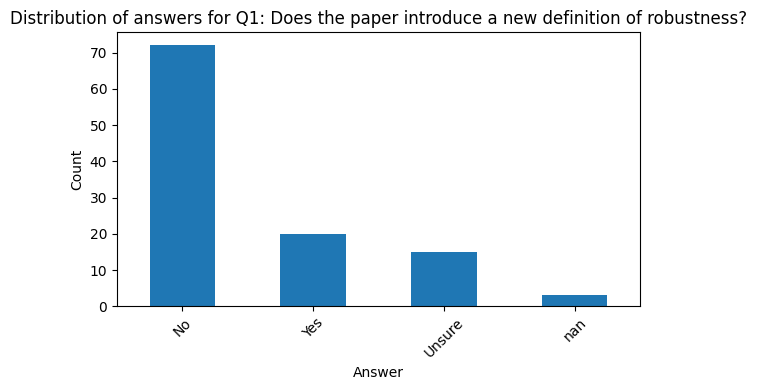

Q2: Does the paper define robustness or risk, either explicitly or implicitly? If yes, what is the definition? (Short answers: concise definition(s), Not provided, Unsure)


/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_64604/2061679310.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


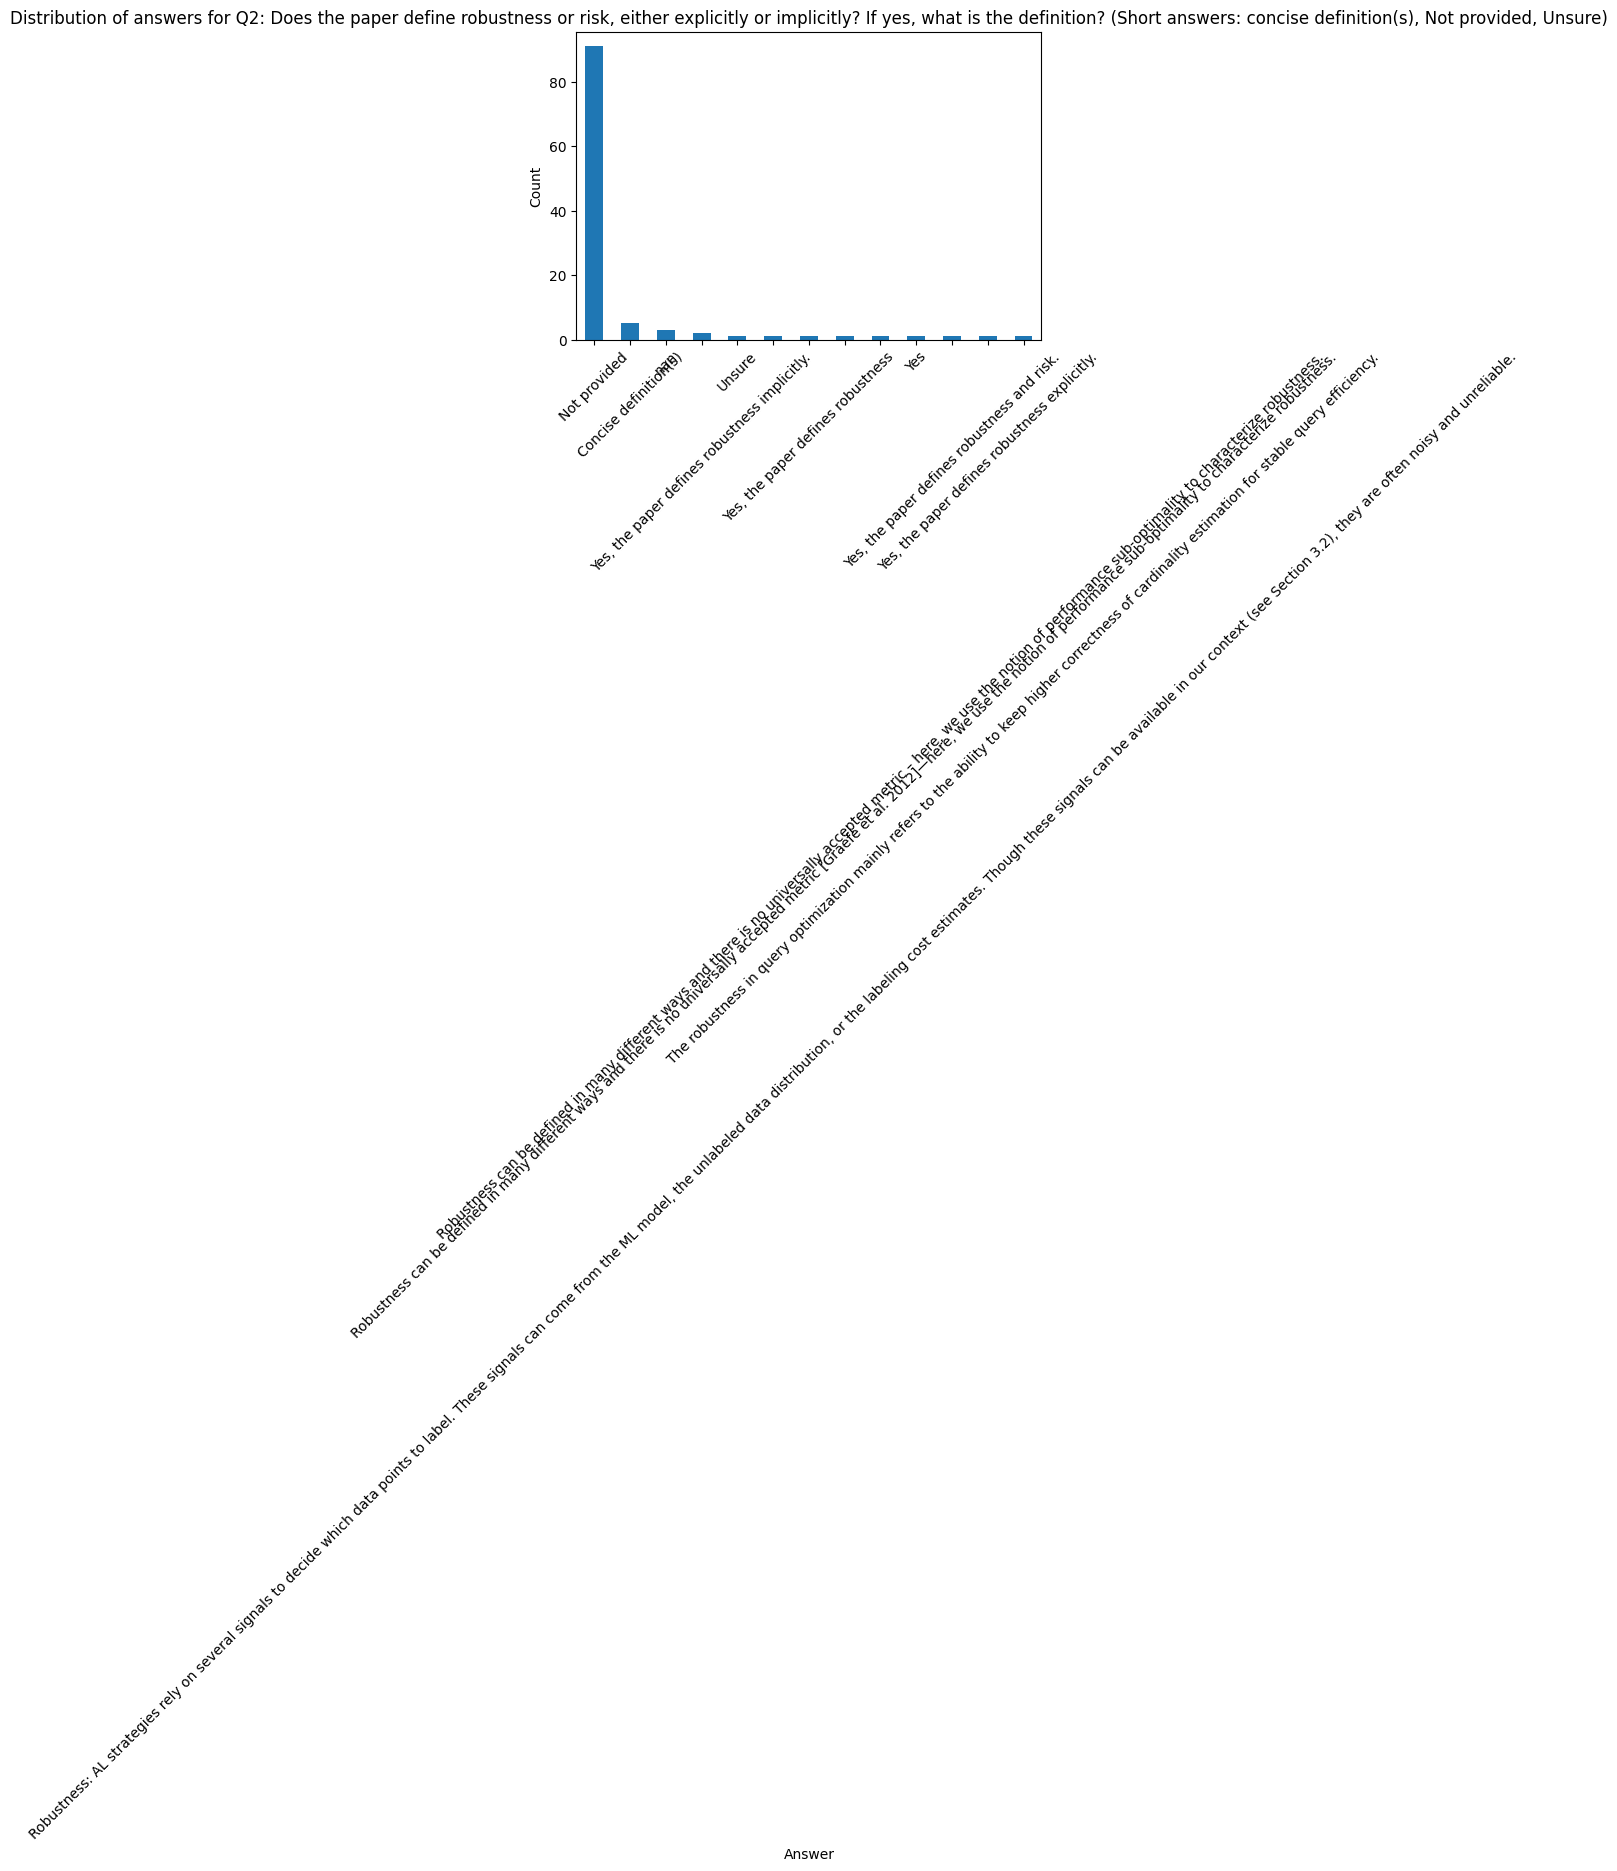

Q3: If a new definition of robustness is given, what aspect of the system does it apply to (e.g., join ordering, DBMS, ML models)? If unclear, say 'Unsure'.


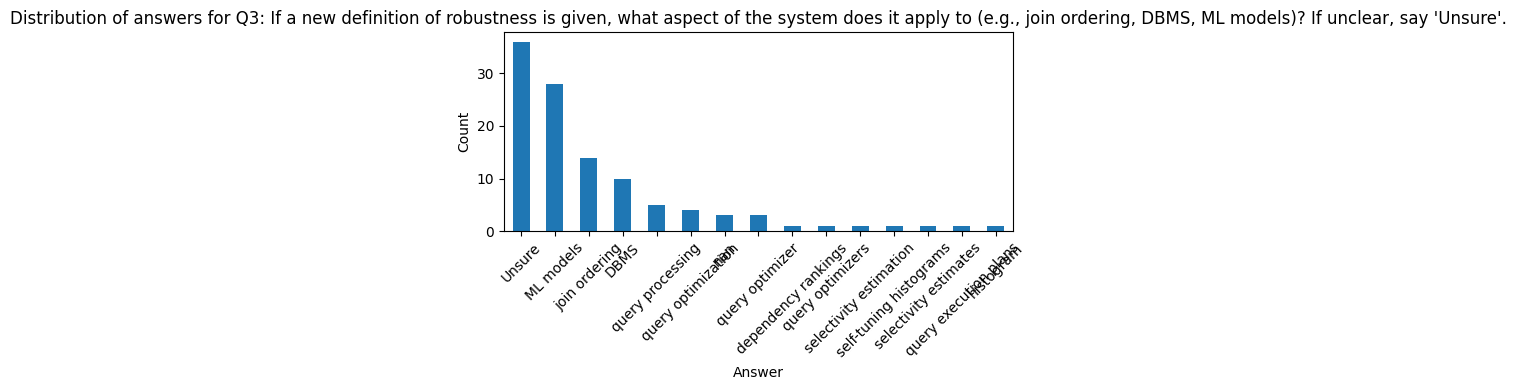

Q4: Does the paper address robustness in query optimization or processing? (Short answers: Yes, No, Unsure)


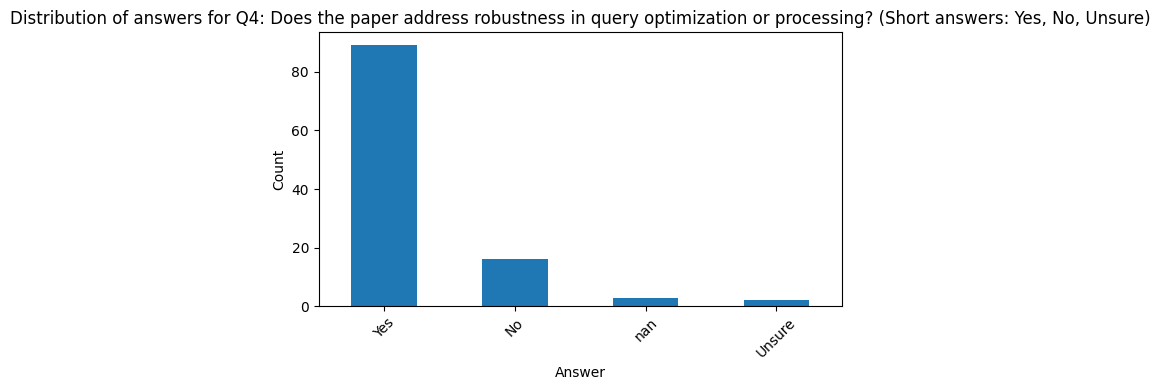

Q5: Does the study contribute to theoretical advancements in the field? (Short answers: Yes, No, Unsure)


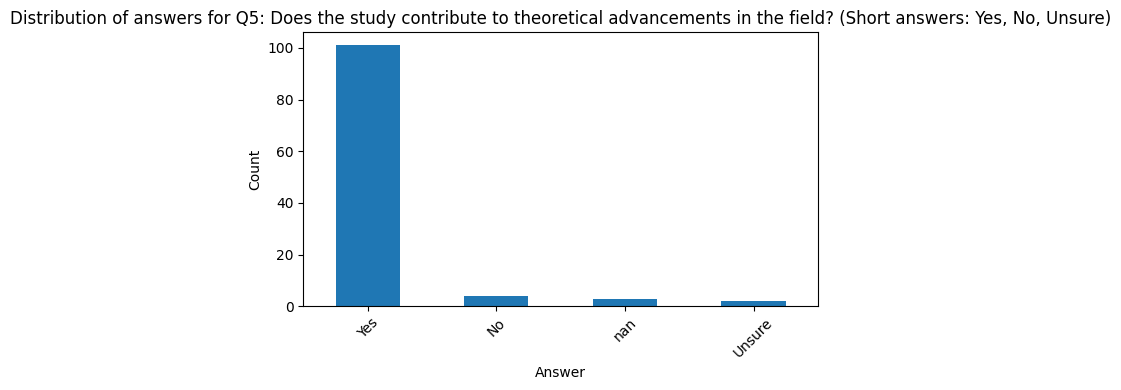

Q6: Is there a significant experimental evaluation included in the paper? (Short answers: Yes, No, Unsure)


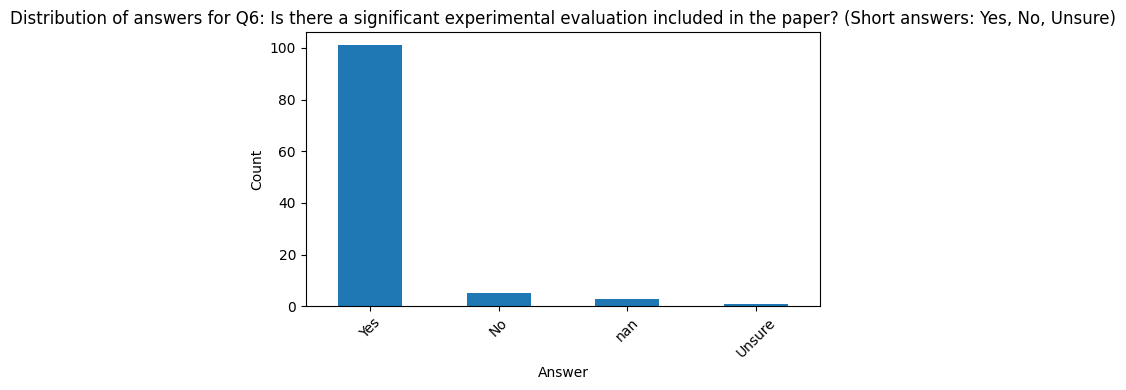

Q7: What type of evaluation method is used to assess robustness (e.g., experimental results, theoretical analysis)? If not provided, say 'Not provided'.


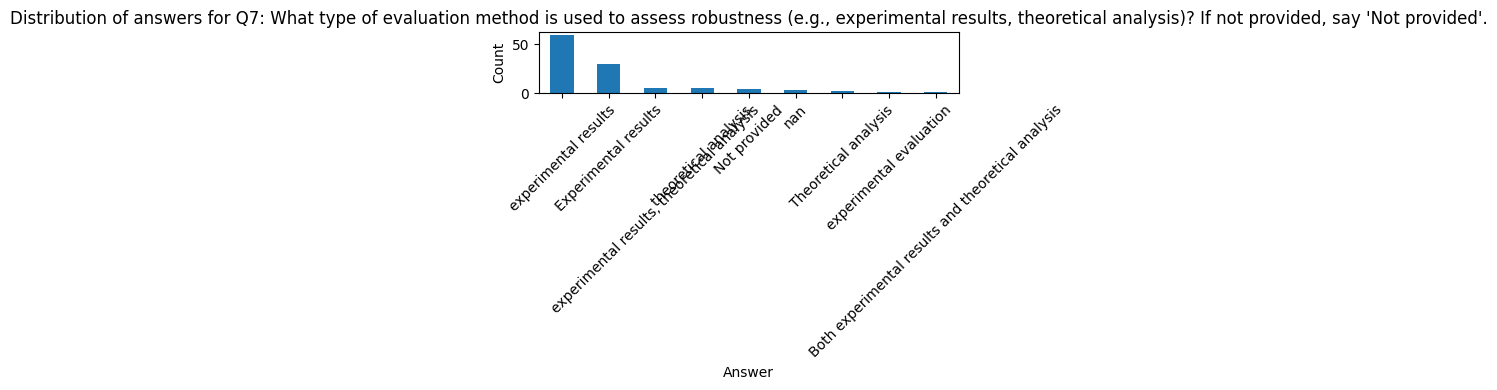

Q8: Does the proposed method aim to improve robustness? (Short answers: Yes, No, Unsure)


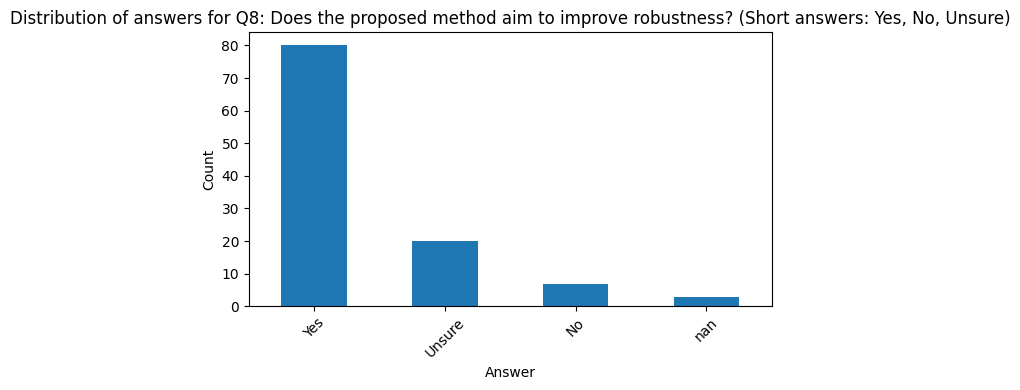

Q9: Which metrics or indicators are used in the paper to evaluate robustness? List them if mentioned, otherwise say 'Not provided'.


/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_64604/2061679310.py:16: UserWarning: Glyph 119878 (\N{MATHEMATICAL ITALIC CAPITAL S}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_64604/2061679310.py:16: UserWarning: Glyph 119877 (\N{MATHEMATICAL ITALIC CAPITAL R}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_64604/2061679310.py:16: UserWarning: Glyph 119862 (\N{MATHEMATICAL ITALIC CAPITAL C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_64604/2061679310.py:16: UserWarning: Glyph 119864 (\N{MATHEMATICAL ITALIC CAPITAL E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_64604/2061679310.py:16: UserWarning: Glyph 119901 (\N{MATHEMATICAL ITALIC SMALL P}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/v

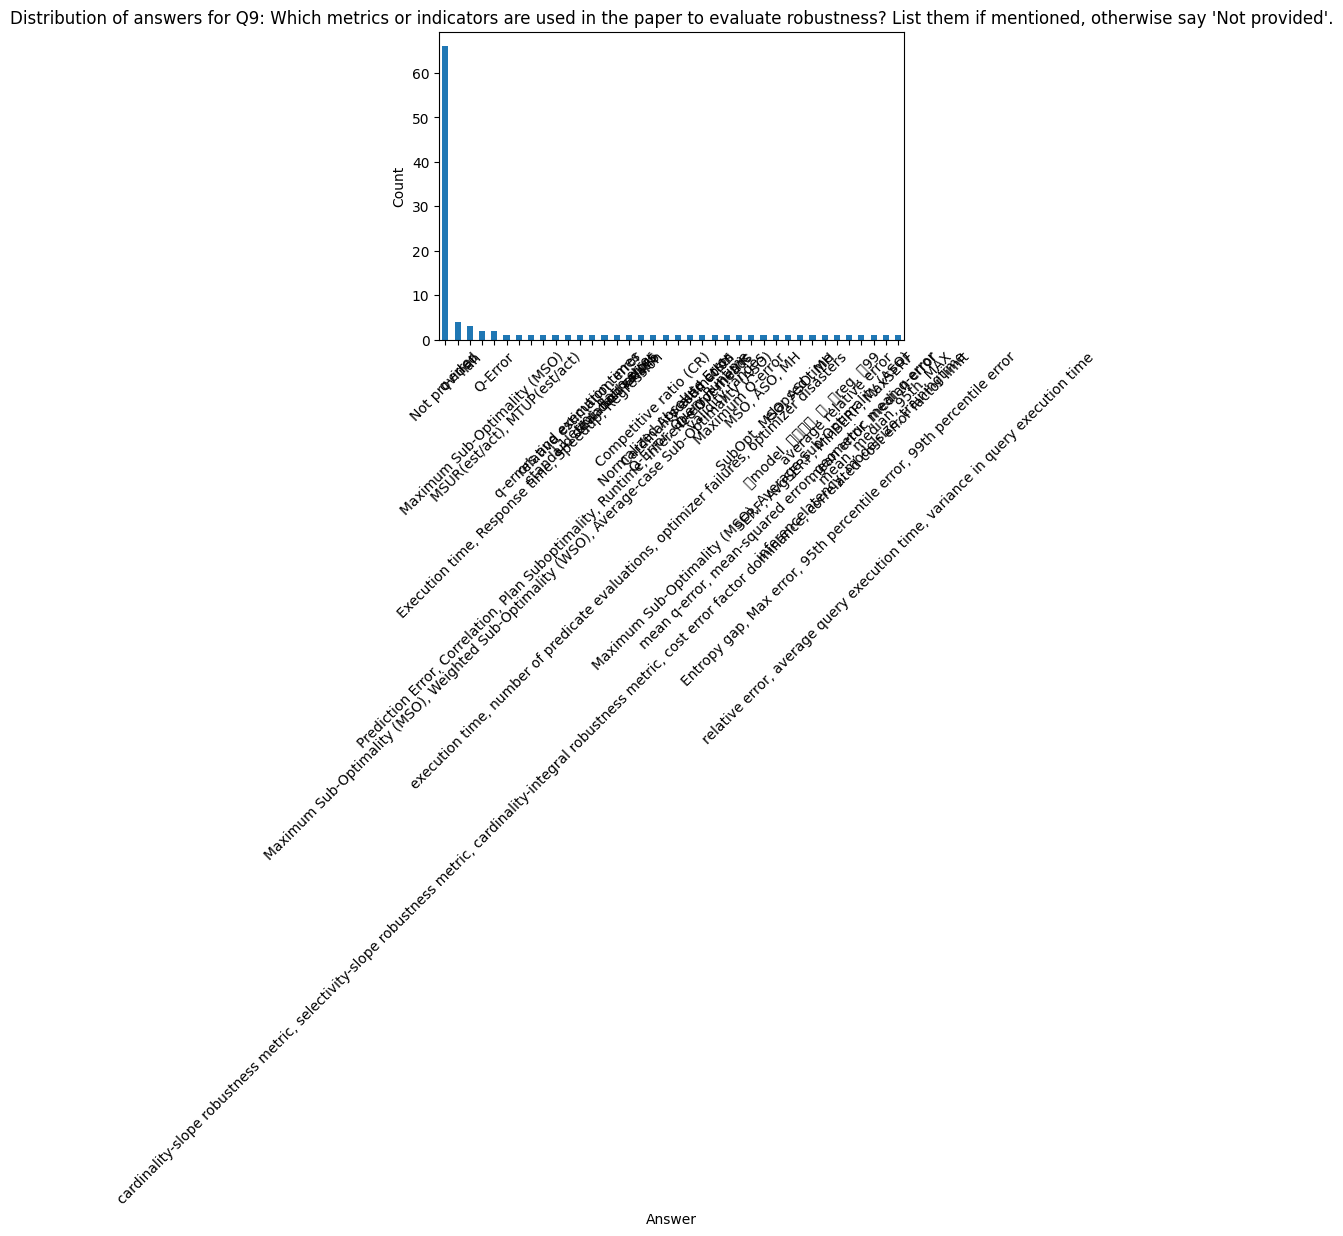

Q10: Which benchmarks are used in the experiments? (Short answers: JOB, TPC-DS, TPC-H, Stack, CEB, DSB, [a list of the other benchmarks used], Not provided, Unsure)


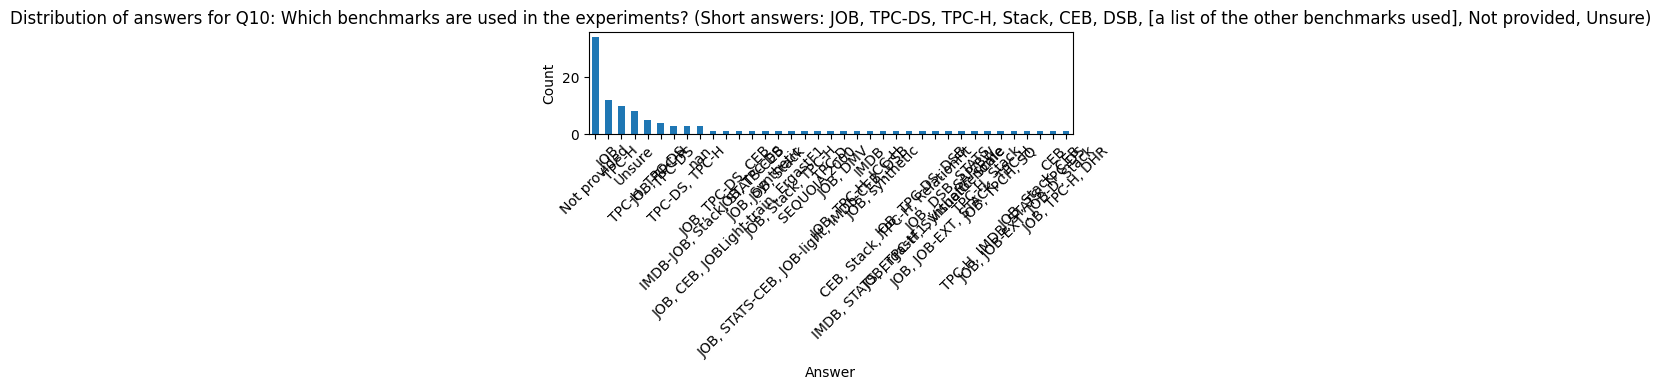

Q11: Are the benchmarks used in the study real, synthetic, or both? (Short answers: Real, Synthetic, Both, Not provided, Unsure)


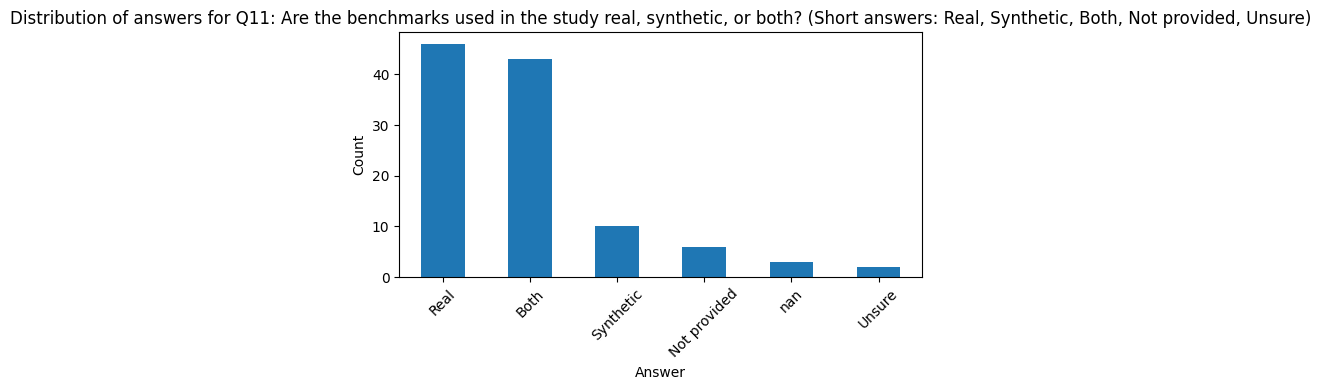

Q12: Does the paper control any characteristics during training data, query, or plan generation (e.g., distribution, selectivity, join patterns)? If yes, list them. Otherwise, say 'Not provided'.


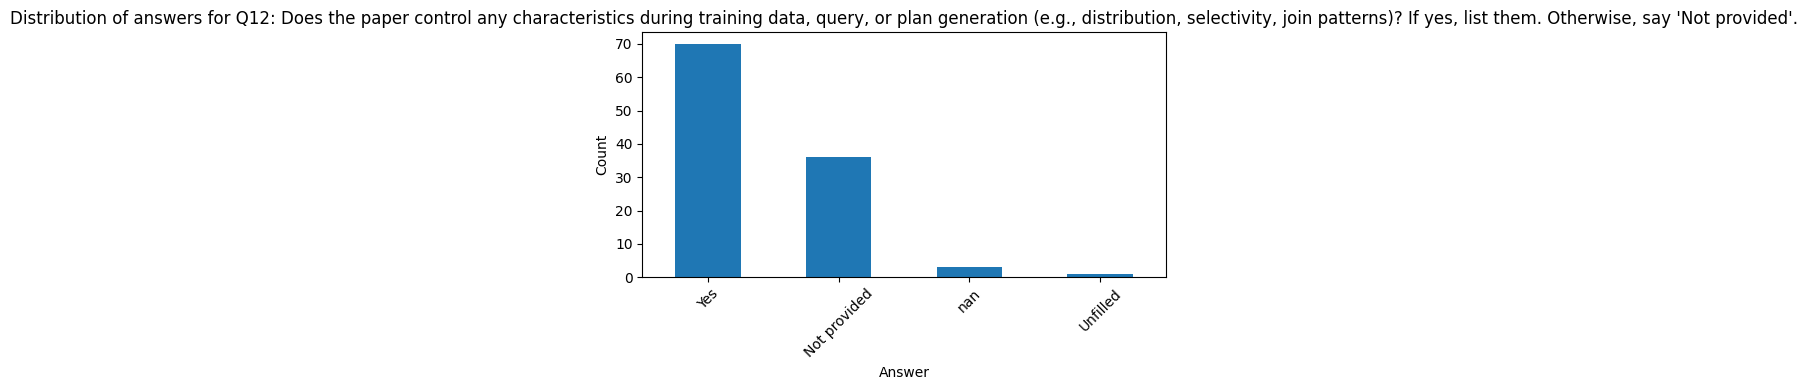

Q13: Are the experiments explicitly designed to evaluate robustness? (Short answers: Yes, No, Unsure)


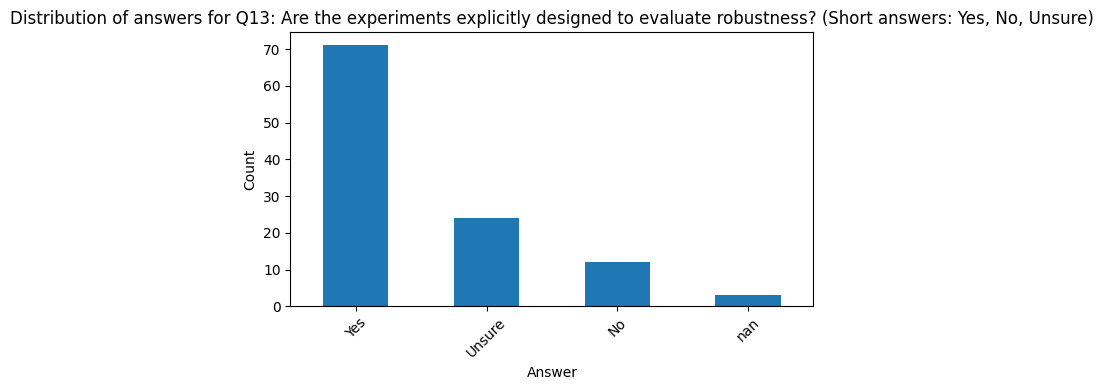

Q14: Does the proposed method use machine learning?


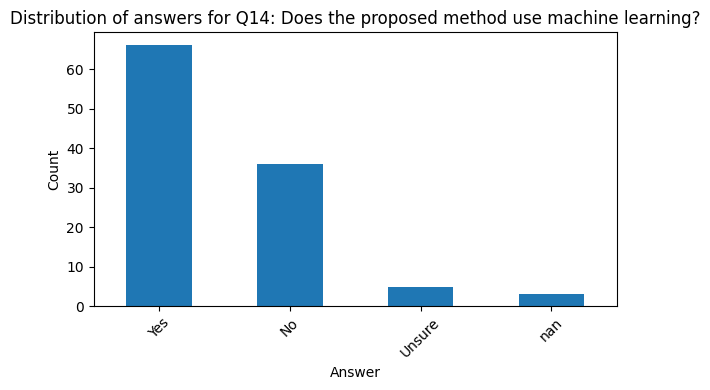

Q15: What type of machine learning is used in the method? (Short answers: Supervised, Unsupervised, Semi-supervised, Reinforcement, Other, Not provided, Unsure)


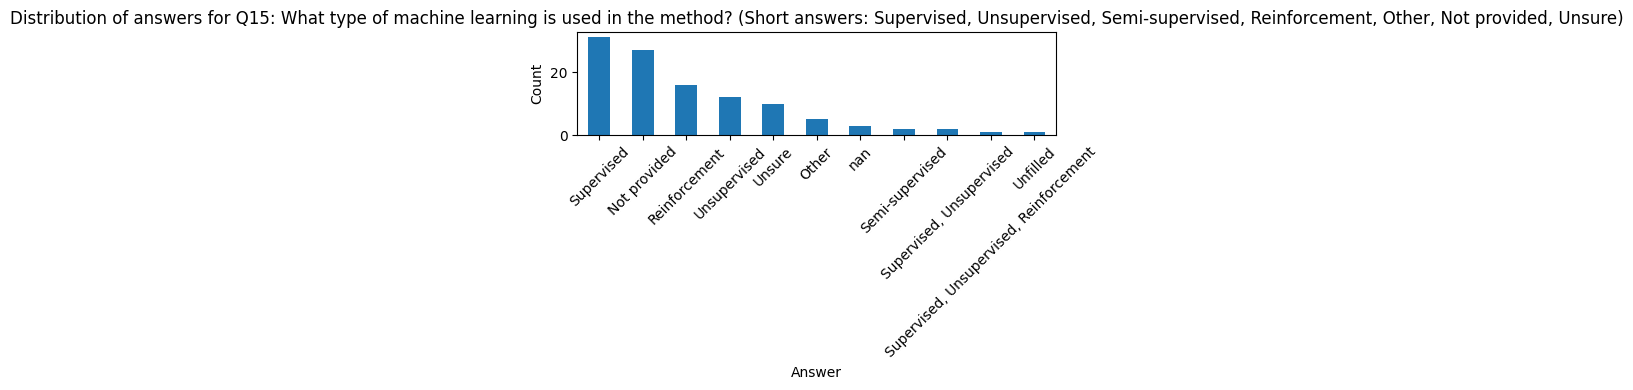

Q16: What is the machine learning category of the proposed method? (Short answers: Regression, Classification, Learning-to-Rank, Autoregression, Clustering, Other, Not provided, Unsure)


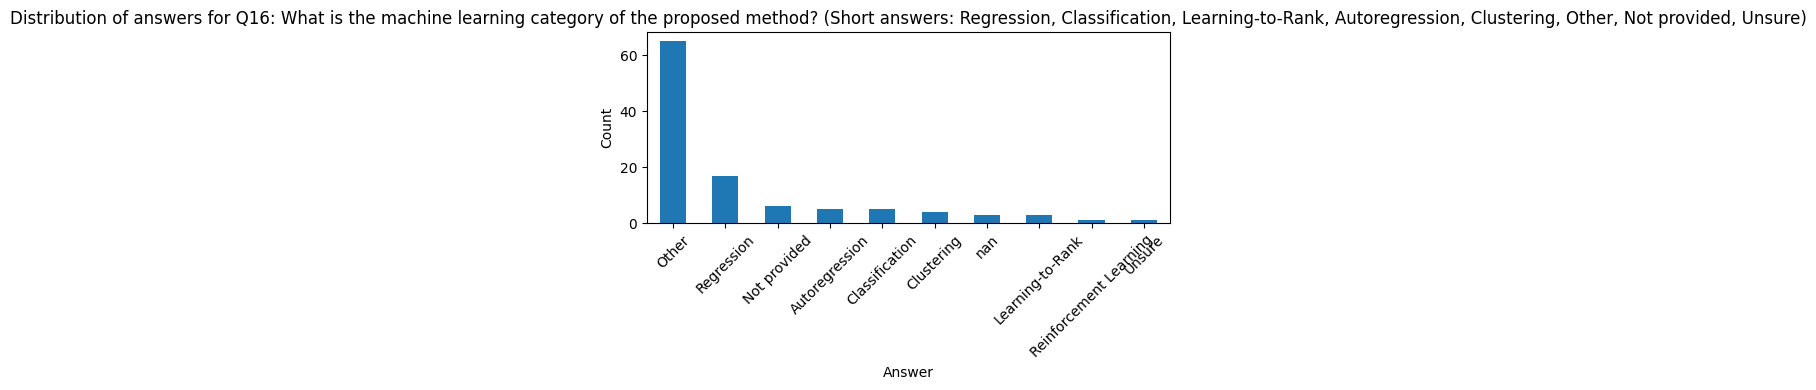

Q17: Does the method use deep learning models?


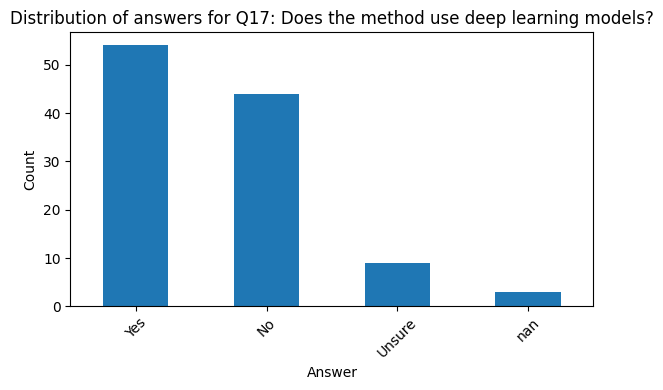

Q18: Does the approach use transfer learning?


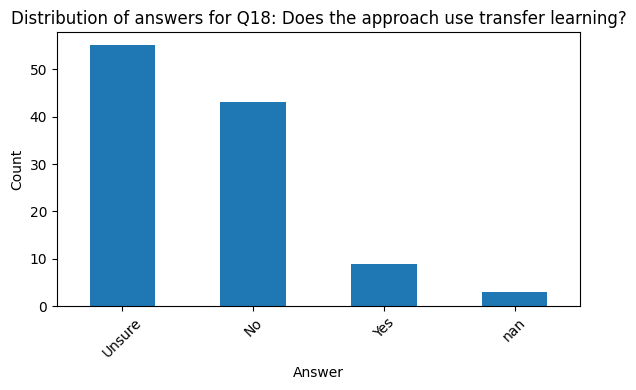

Q19: How is training data generated in the study? If a generation method is described, summarize it. If not mentioned, say 'Not provided'.


/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_64604/2061679310.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


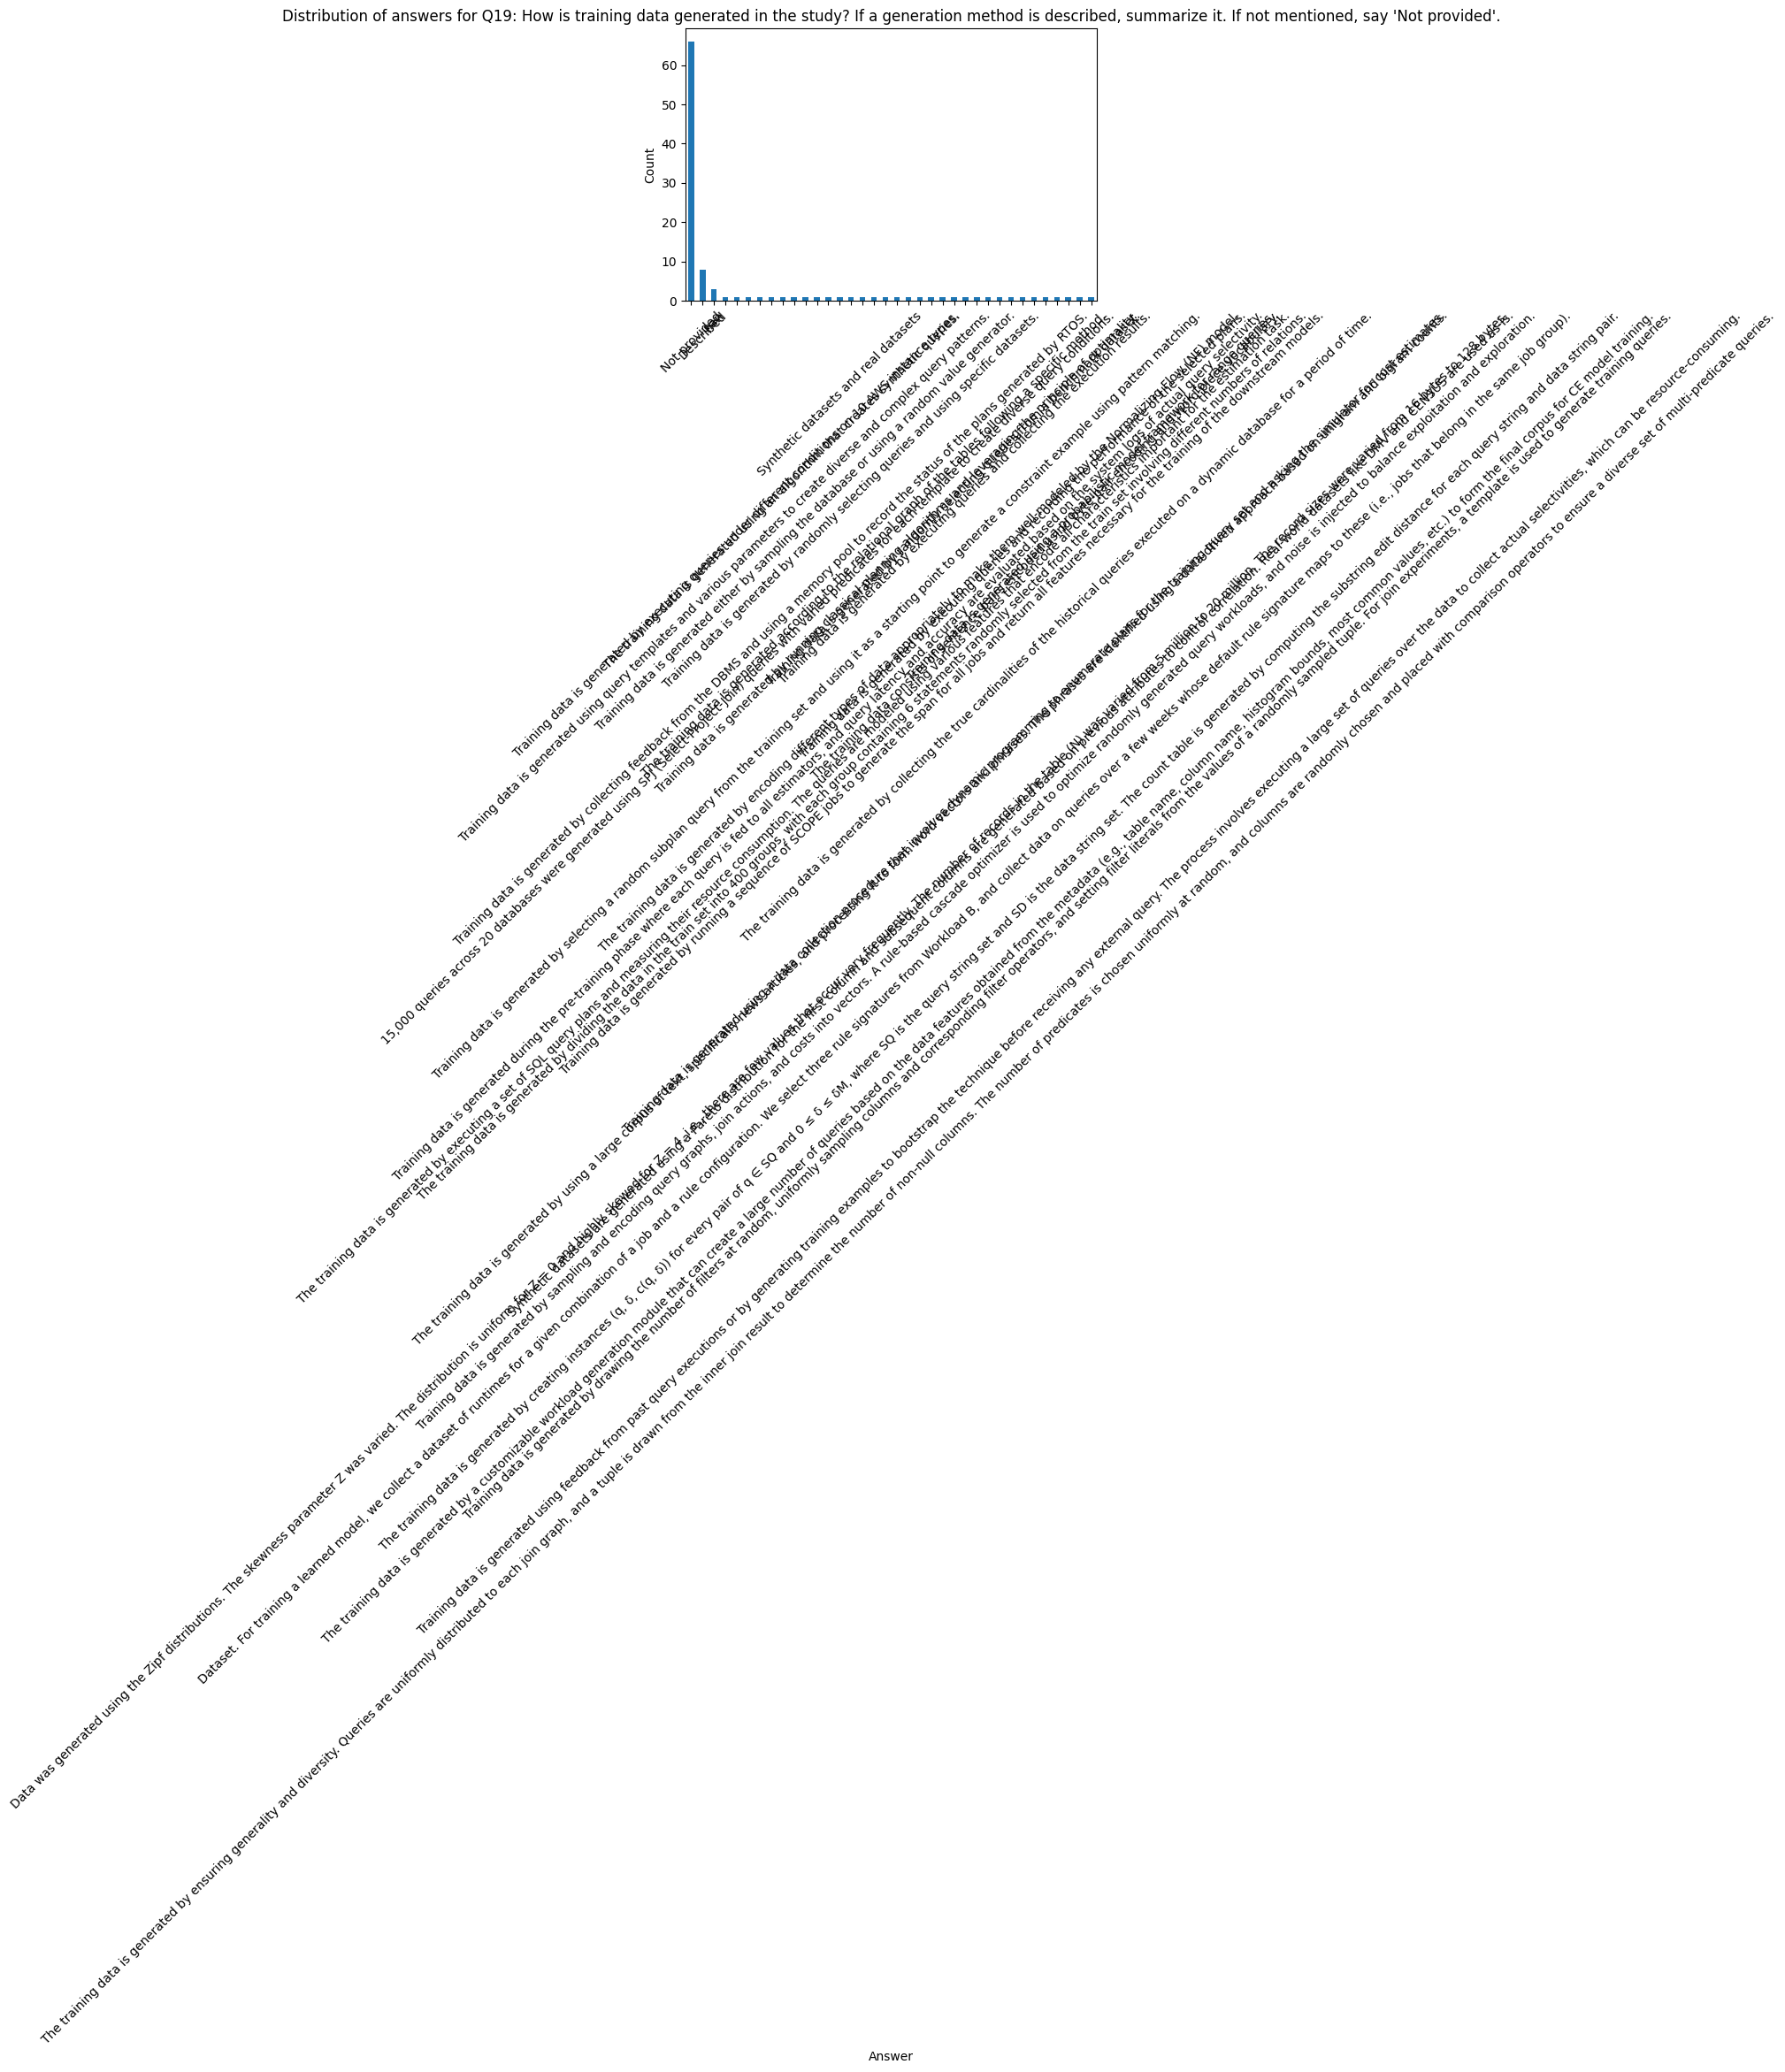

Q20: How are input samples represented or encoded in the study (e.g., feature vectors, trees, graphs)? If the encoding process is not discussed, say 'Not provided'.


/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_64604/2061679310.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


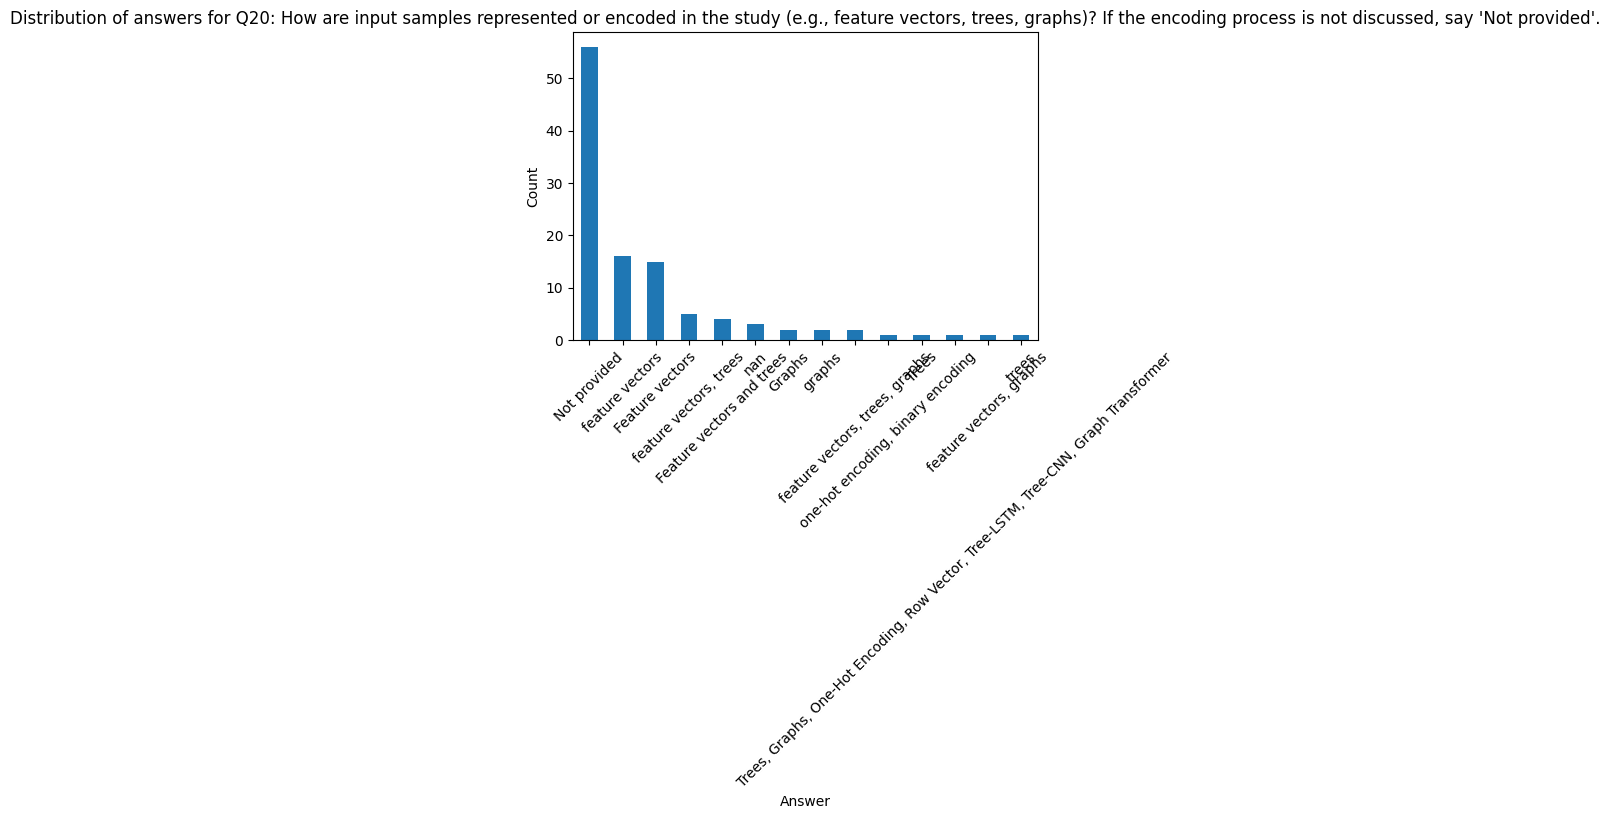

Q21: Does the study handle predictive uncertainty in any way? (Short answers: Yes, No, Unsure)


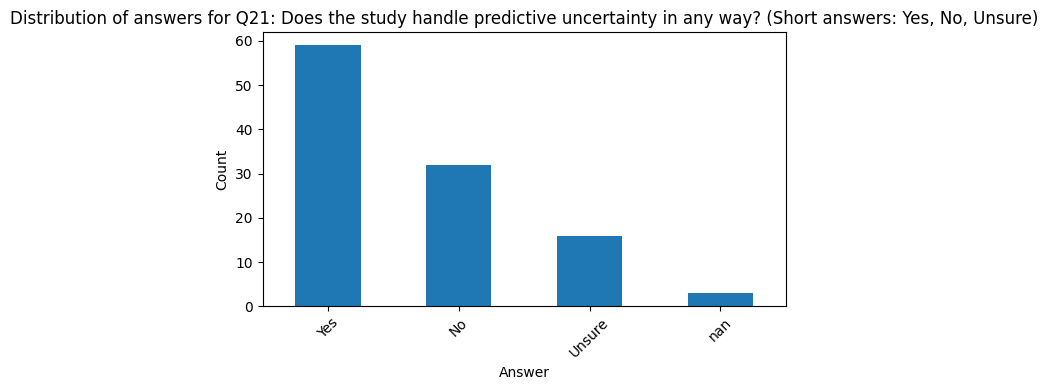

Q22: Does the study consider generalization to out-of-distribution data as part of robustness? (Short answers: Yes, No, Unsure)


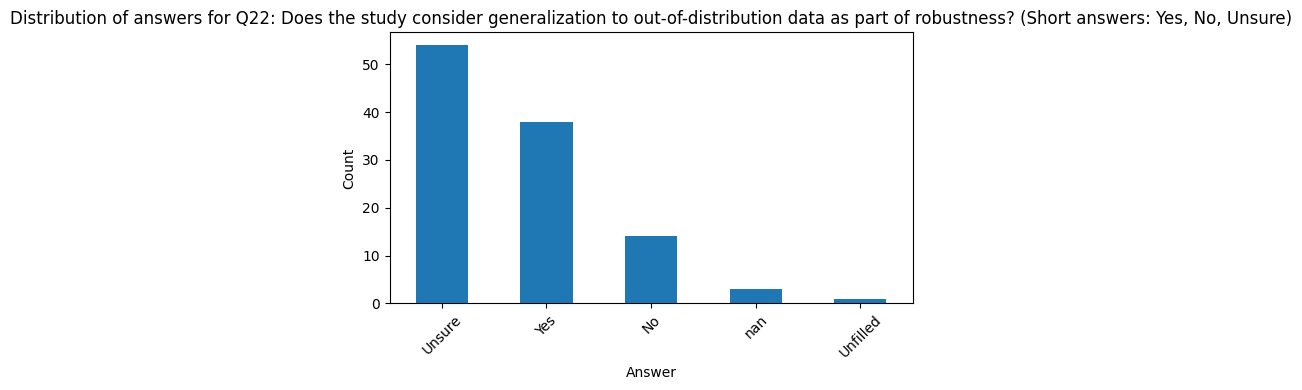

Q23: Does the study evaluate generalization to out-of-distribution scenarios?


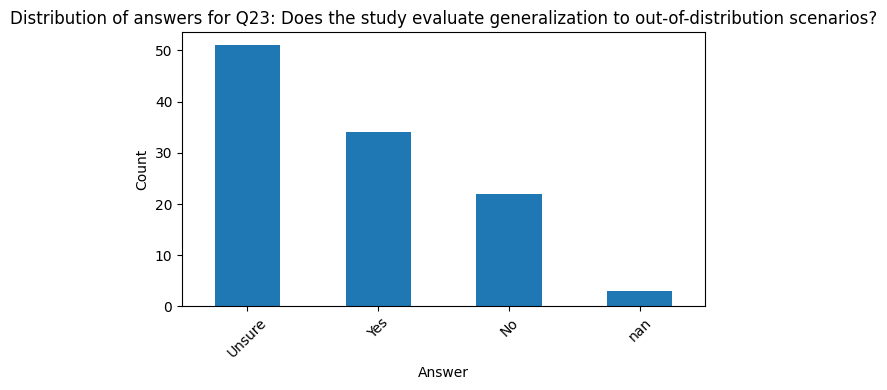

Q24: Which model architecture is used in the proposed method (excluding baselines)? (Short answers: MLP, RNN, MSCN, TCNN, Tree-LSTM, BDT, GNN, Transformer, Other, Not provided, Unsure)


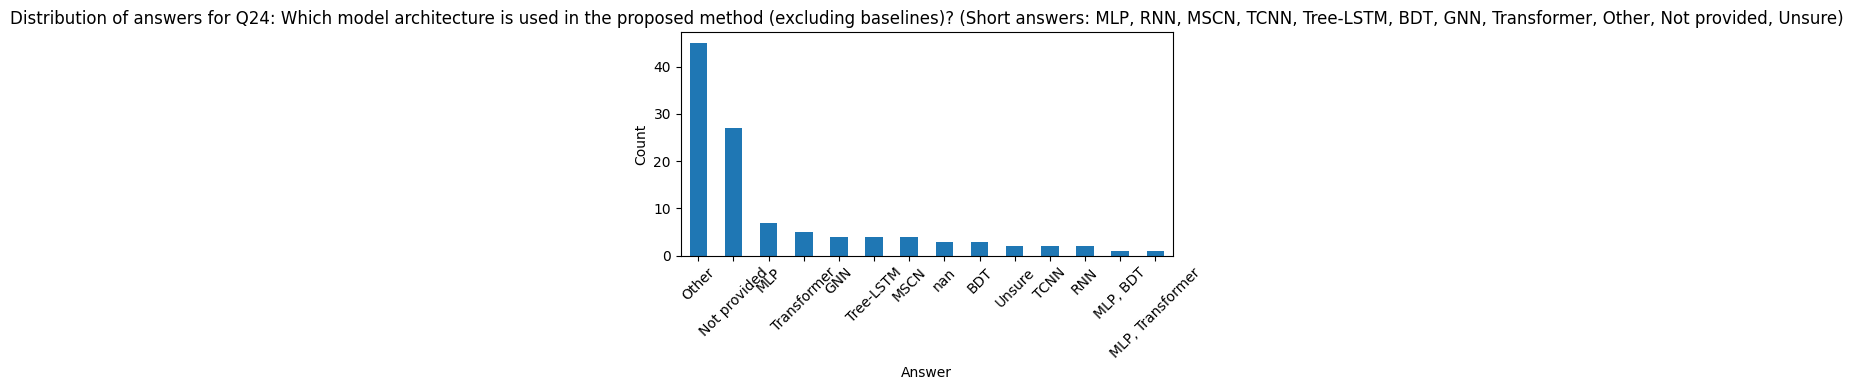

Q25: Was improving robustness the main motivation behind the model or encoding design? (Short answers: Yes, No, Unsure)


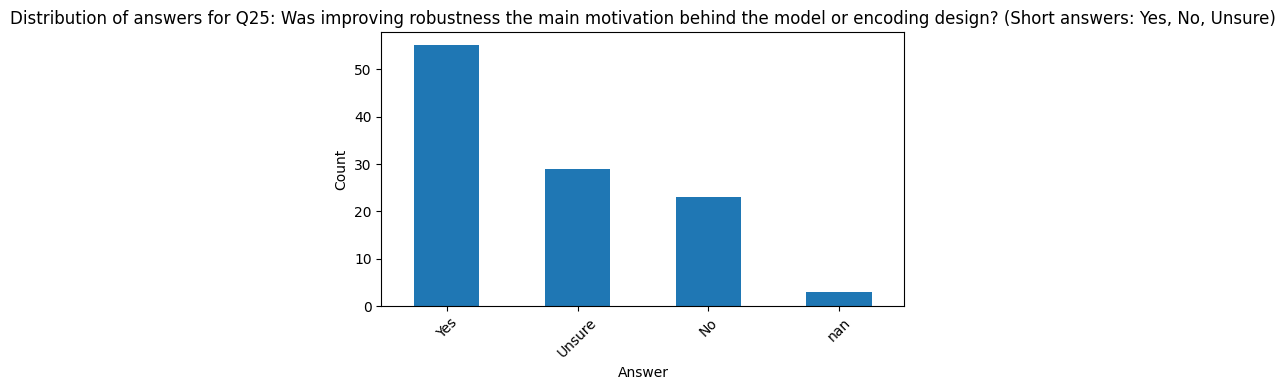

Q26: Aside from the main approach, does the paper mention any additional techniques to enhance robustness? If yes, list them. Otherwise, say 'Not provided'.


/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_64604/2061679310.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


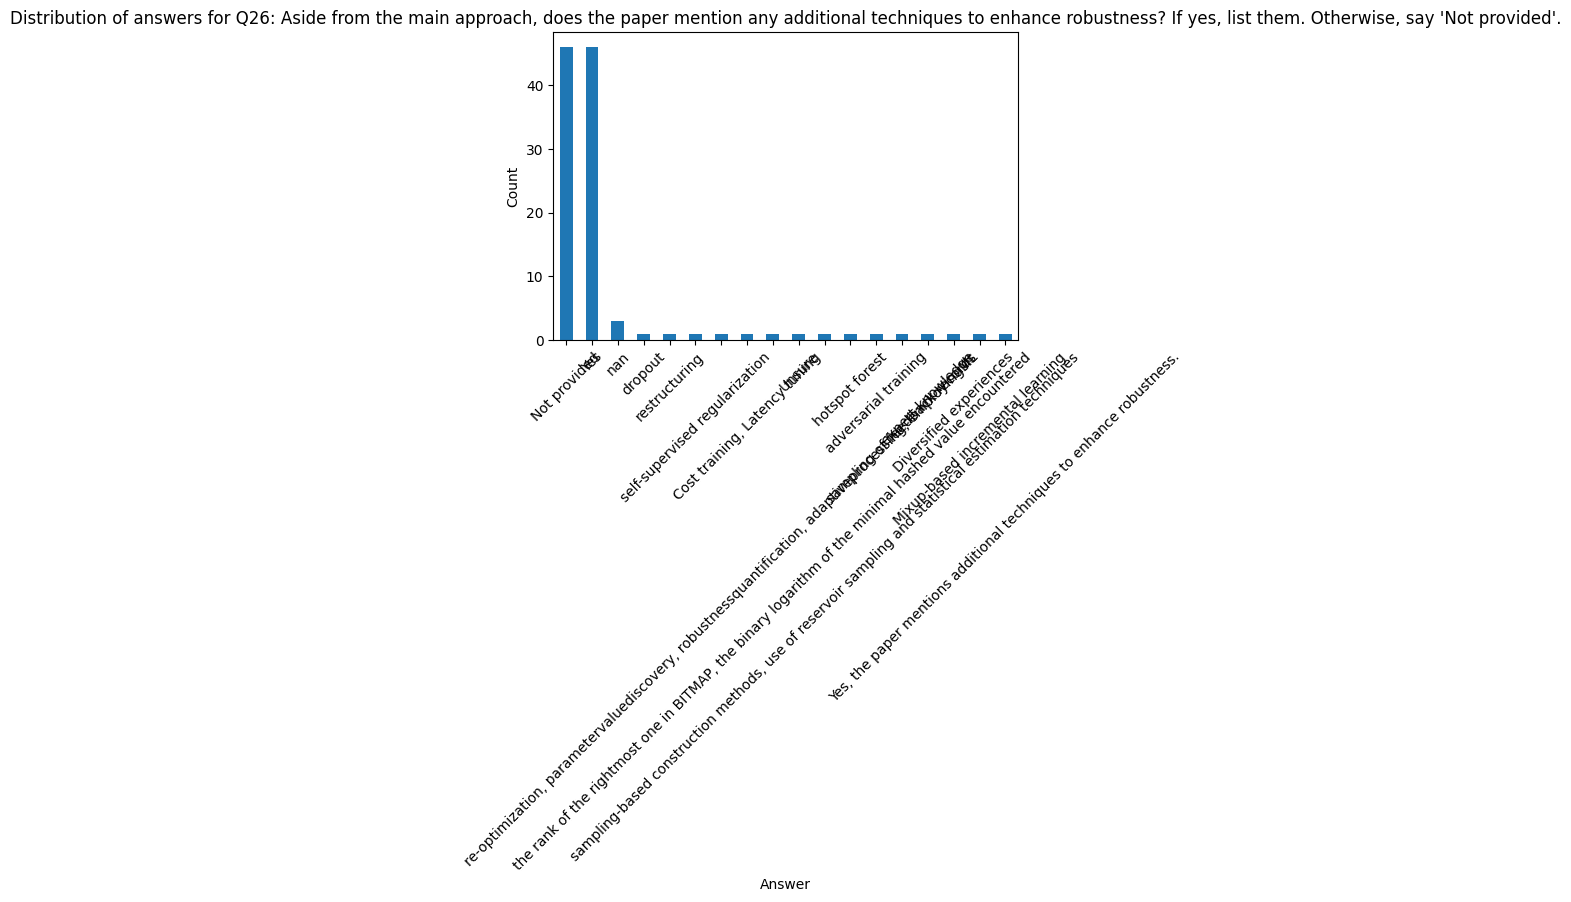

In [15]:
# plot distribution of values in "Q1-ShortAnswer" column

i = 1
for q in range(i, 27):
    questionText = general_df[f"Q{q}-QuestionText"].iloc[0]
    print(f"Q{q}: {questionText}")
    
    counts = general_df[f"Q{q}-ShortAnswer"].value_counts(dropna=False)  # include NaN if needed    
    
    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar')
    plt.title(f'Distribution of answers for Q{q}: {questionText}')
    plt.xlabel('Answer')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

## Trends within Task Type in Machine Learning

In [16]:
allCategories = cited_df[["Q16-ShortAnswer","Published Year", "Q24-ShortAnswer", "Q10-ShortAnswer", "Q21-ShortAnswer", "Q23-ShortAnswer", "Q20-ShortAnswer", "Q15-ShortAnswer"]]
allCategories.columns = ["Task Type","Year", "Architecture", "Benchmark", "Uncertainty", "OOD", "Encoding", "Learning Paradigm"]
allCategories=allCategories.reset_index(drop=True)

# exclude "Not Applicable" and "Unsure"
allCategories = allCategories[allCategories["Task Type"] != "Not provided"]
allCategories = allCategories[allCategories["Task Type"] != "Unsure"]
allCategories = allCategories[allCategories["Architecture"] != "Not provided"]
allCategories = allCategories[allCategories["Architecture"] != "Unsure"]
allCategories = allCategories[allCategories["Benchmark"] != "Not provided"]
allCategories = allCategories[allCategories["Uncertainty"] != "Unsure"]
allCategories = allCategories[allCategories["OOD"] == "Yes"]
allCategories = allCategories[allCategories["Encoding"] != "Not provided"]

In [17]:
allCategories

,Task Type,Year,Architecture,Benchmark,Uncertainty,OOD,Encoding,Learning Paradigm
8,Autoregression,2021,Other,JOB,No,Yes,"one-hot encoding, binary encoding",Semi-supervised
11,Other,2020,Other,"TPC-DS, TPC-H",Yes,Yes,feature vectors,Supervised
16,Other,2023,GNN,CEB,No,Yes,Graphs,Supervised
18,Other,2022,TCNN,"JOB, TPC-H",Yes,Yes,feature vectors,Reinforcement
19,Other,2021,TCNN,JOB,Yes,Yes,feature vectors,Reinforcement
26,Other,2022,Tree-LSTM,"JOB, JOB-EXT, JOB-D, Stack",Yes,Yes,"feature vectors, trees",Reinforcement
37,Regression,2021,Other,JOB,Yes,Yes,feature vectors,Supervised
38,Learning-to-Rank,2024,Other,"JOB, TPCH, SQ",No,Yes,Trees,Supervised
51,Other,2019,MSCN,JOB,No,Yes,Feature vectors,Supervised
52,Reinforcement Learning,2019,MLP,JOB,Yes,Yes,feature vectors,Reinforcement


### Distribution of Task Type Over all Papers

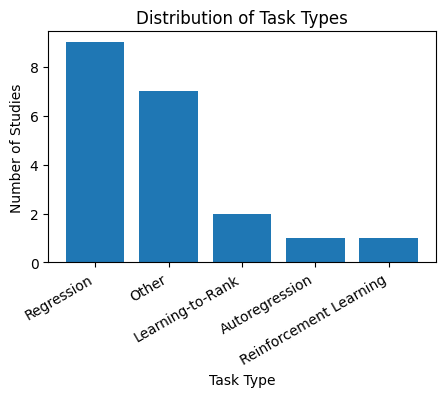

In [18]:
freq = allCategories.loc[:,"Task Type"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(5, 3))
plt.bar(freq.index, freq.values)
plt.xlabel("Task Type")
plt.ylabel("Number of Studies")
plt.title("Distribution of Task Types")
plt.xticks(rotation=30, ha='right')  # Rotates the x-tick labels by 30 degrees
plt.show()

### Distribution of Task Type Over all Papers Over Time

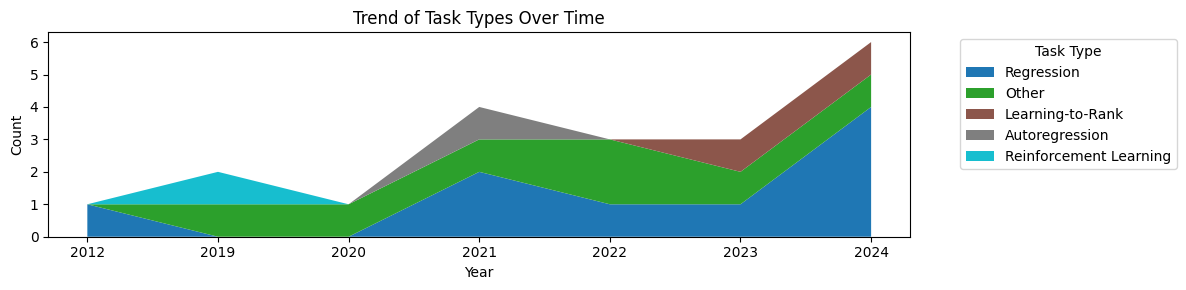

In [19]:
# Group by 'Year' and 'Task Type' to count the number of occurrences for each combination
category_trend = allCategories.groupby(['Year', 'Task Type']).size().reset_index(name='Count')

# Pivot the table so that each category becomes a column and fill missing values with 0
pivot_table = category_trend.pivot(index='Year', columns='Task Type', values='Count').fillna(0)

# Ensure the data is sorted by Year
pivot_table.sort_index(inplace=True)

# Sort the columns by total frequency (sum over years) in descending order
total_counts = pivot_table.sum(axis=0)
sorted_categories = total_counts.sort_values(ascending=False).index
pivot_table = pivot_table[sorted_categories]

# Prepare the data for the stackplot
years = pivot_table.index.values
stack_data = [pivot_table[col].values for col in pivot_table.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(pivot_table.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=pivot_table.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trend of Task Types Over Time")
plt.legend(title="Task Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

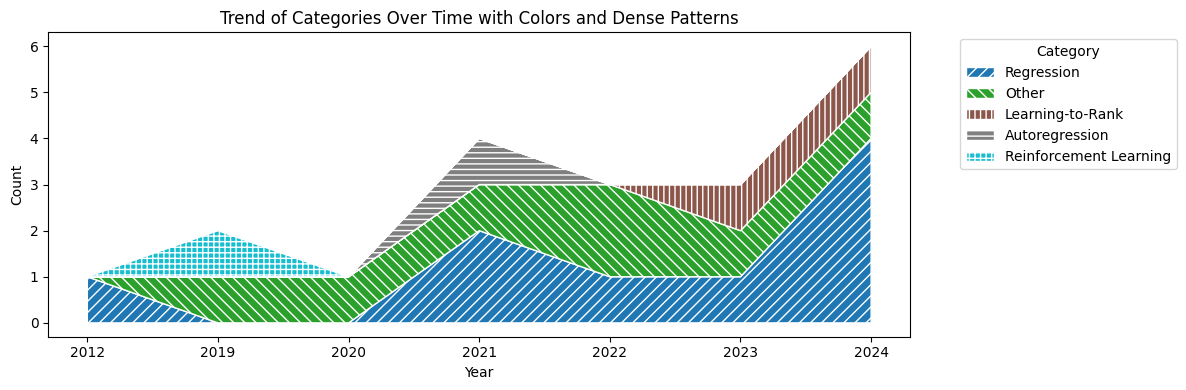

In [20]:
# Assuming pivot_table is defined and sorted by total frequency as before
years = pivot_table.index.values
stack_data = [pivot_table[col].values for col in pivot_table.columns]

# Compute the cumulative sum for stacking.
cumulative = np.cumsum(stack_data, axis=0)

# Generate a pastel color palette using the 'Pastel1' colormap.
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(pivot_table.columns))]

# Define a list of hatch patterns with increased density.
hatches = ['///', '\\\\\\', '|||', '---', '+++', 'xxx', 'ooo', 'OOO', '...', '***']

plt.figure(figsize=(12, 4))

# Plot the first category from 0 to the first cumulative sum.
plt.fill_between(
    years, 
    0, 
    cumulative[0], 
    facecolor=colors[0], 
    edgecolor='white', 
    hatch=hatches[0],
    label=pivot_table.columns[0]
)

# For each subsequent category, fill between the previous and current cumulative values.
for i in range(1, len(stack_data)):
    plt.fill_between(
        years, 
        cumulative[i-1], 
        cumulative[i], 
        facecolor=colors[i], 
        edgecolor='white', 
        hatch=hatches[i % len(hatches)],
        label=pivot_table.columns[i]
    )

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trend of Categories Over Time with Colors and Dense Patterns")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Distribution of Learning Pardigm per Task Type

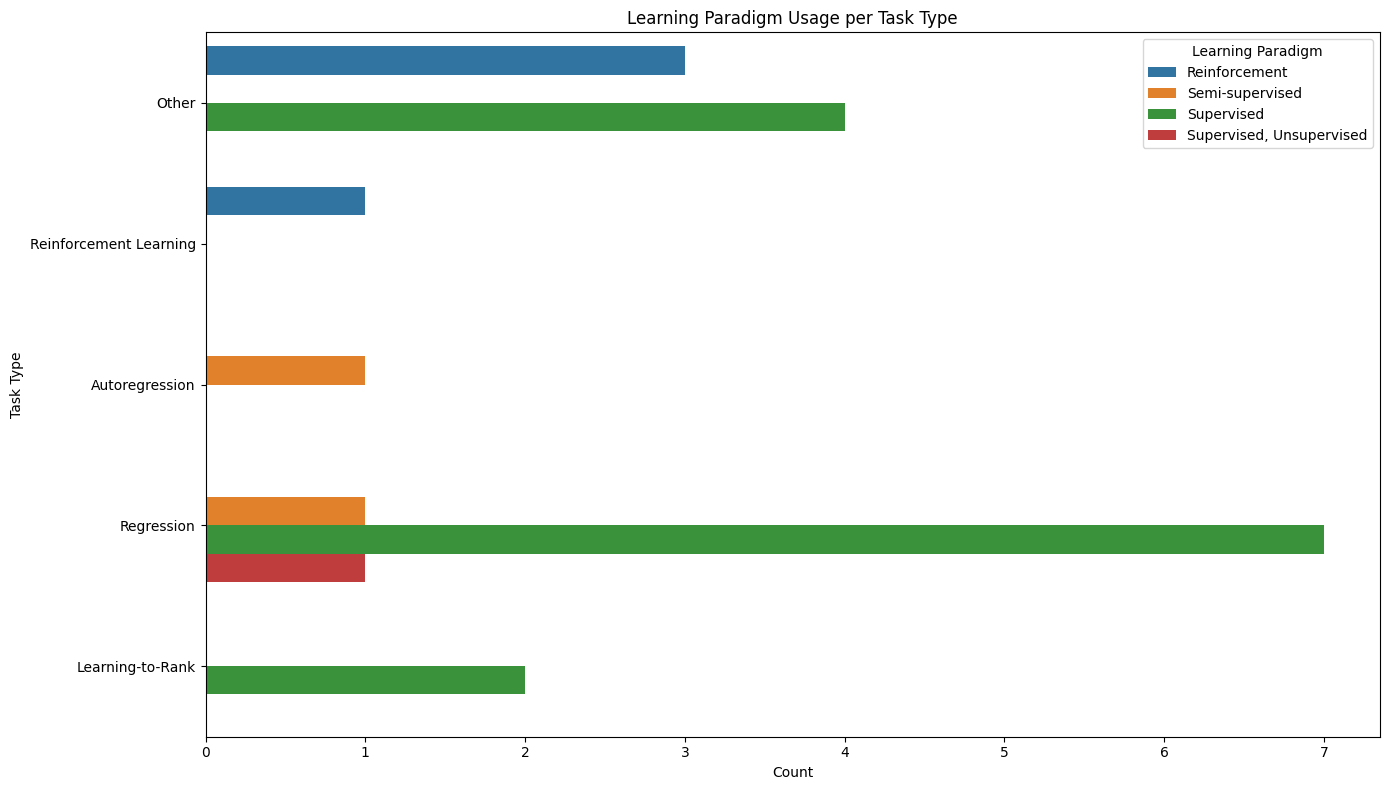

In [21]:
learning_counts = allCategories.groupby(['Learning Paradigm', 'Task Type']).size().reset_index(name='Count')

plt.figure(figsize=(14, 8))
sns.barplot(data=learning_counts, x='Count', y='Task Type', hue='Learning Paradigm')
plt.title("Learning Paradigm Usage per Task Type")
plt.tight_layout()
plt.show()

### Distribution of Architecture per Task Type

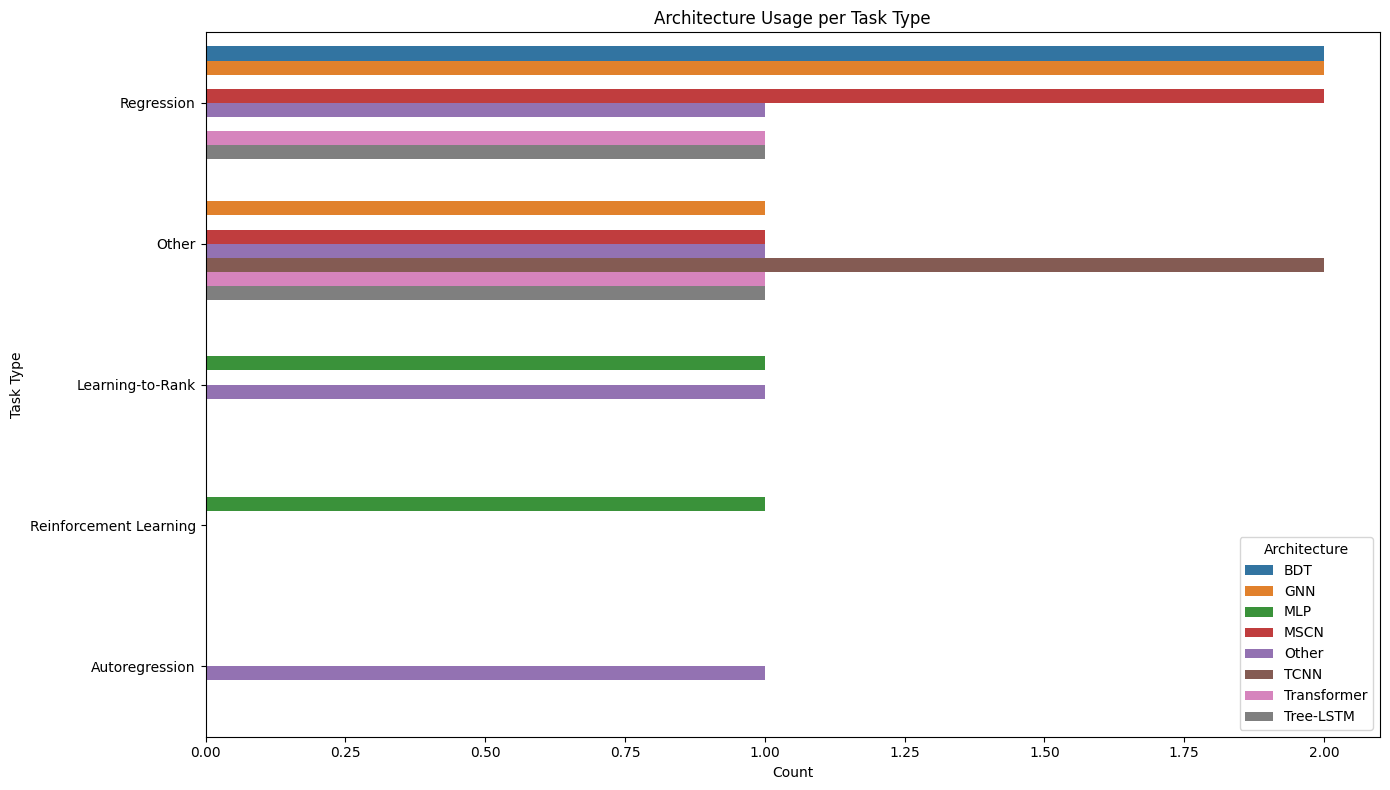

In [22]:
arch_counts = allCategories.groupby(['Architecture', 'Task Type']).size().reset_index(name='Count')

plt.figure(figsize=(14, 8))
sns.barplot(data=arch_counts, x='Count', y='Task Type', hue='Architecture')
plt.title("Architecture Usage per Task Type")
plt.tight_layout()
plt.show()

### Distribution of Benchmarks used per Task Type

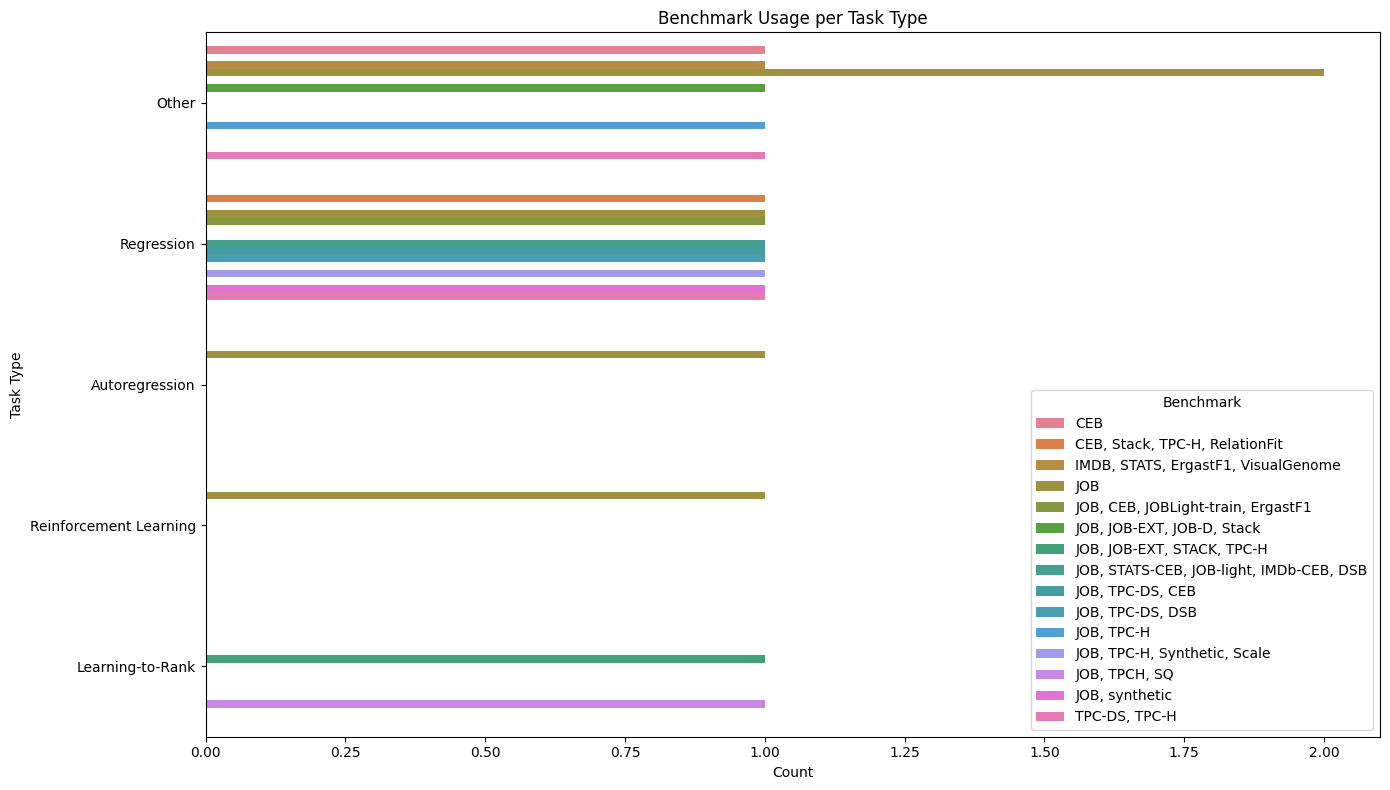

In [23]:
bench_counts = allCategories.groupby(['Benchmark', 'Task Type']).size().reset_index(name='Count')

plt.figure(figsize=(14, 8))
sns.barplot(data=bench_counts, x='Count', y='Task Type', hue='Benchmark')
plt.title("Benchmark Usage per Task Type")
plt.tight_layout()
plt.show()

### Distribution of Techniques that Evaluate Uncertainty per Task Type

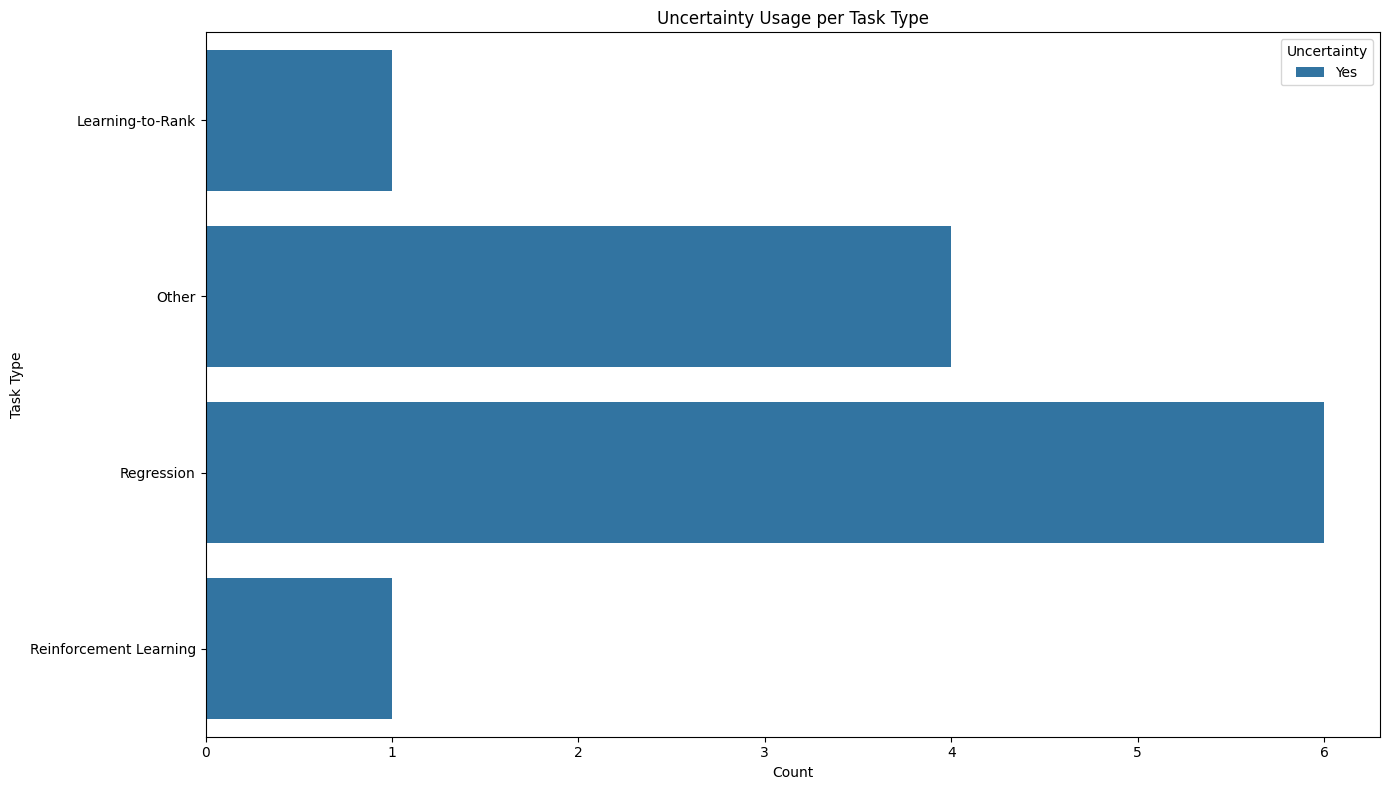

In [24]:
allCategories = allCategories[allCategories['Uncertainty'] == 'Yes']

uncertainty_counts = allCategories.groupby(['Uncertainty', 'Task Type']).size().reset_index(name='Count')

plt.figure(figsize=(14, 8))
sns.barplot(data=uncertainty_counts, x='Count', y='Task Type', hue='Uncertainty')
plt.title("Uncertainty Usage per Task Type")
plt.tight_layout()
plt.show()

### Distribution of Techniques that Evaluate Out of Distribution per Task Type

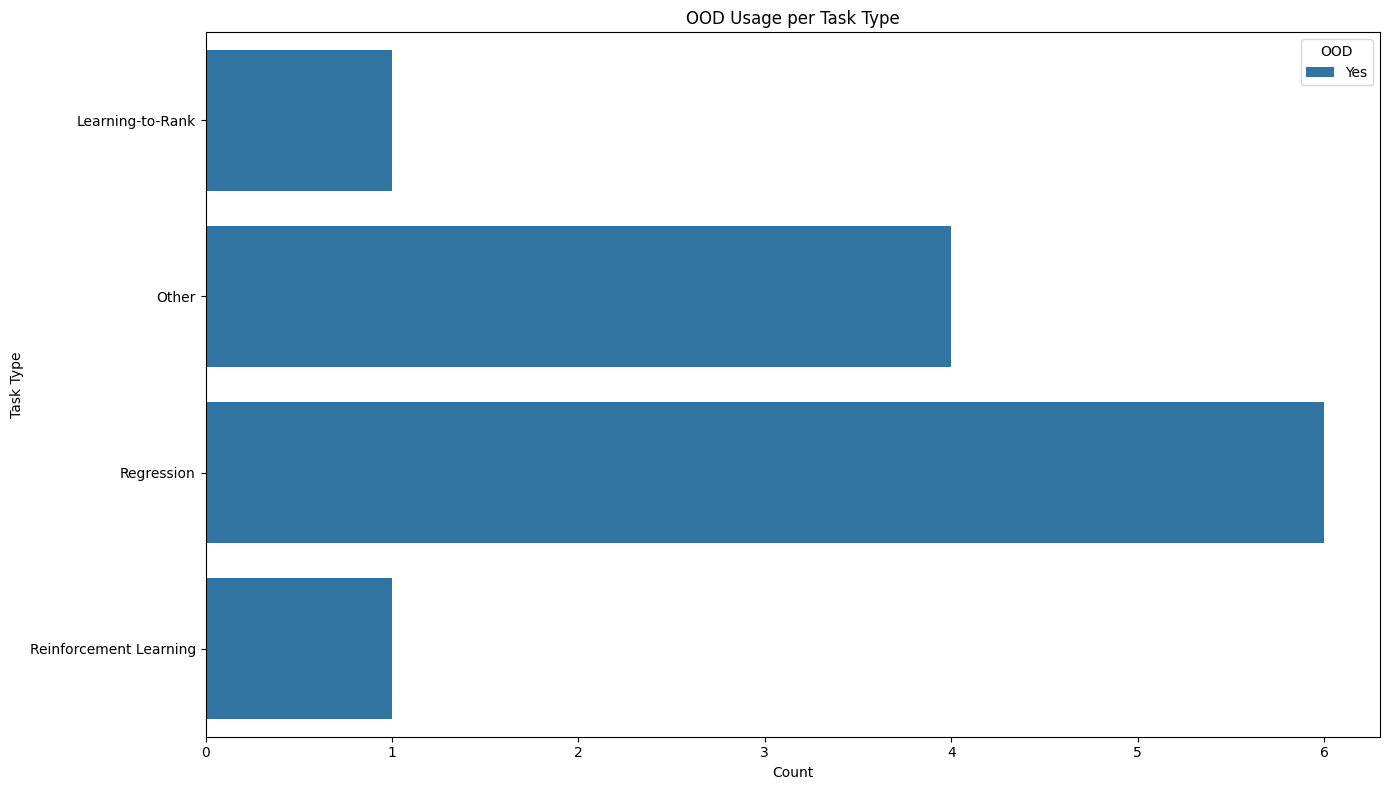

In [25]:
ood_counts = allCategories.groupby(['OOD', 'Task Type']).size().reset_index(name='Count')

plt.figure(figsize=(14, 8))
sns.barplot(data=ood_counts, x='Count', y='Task Type', hue='OOD')
plt.title("OOD Usage per Task Type")
plt.tight_layout()
plt.show()

### Distribution of Encoding Techniques per Task Type

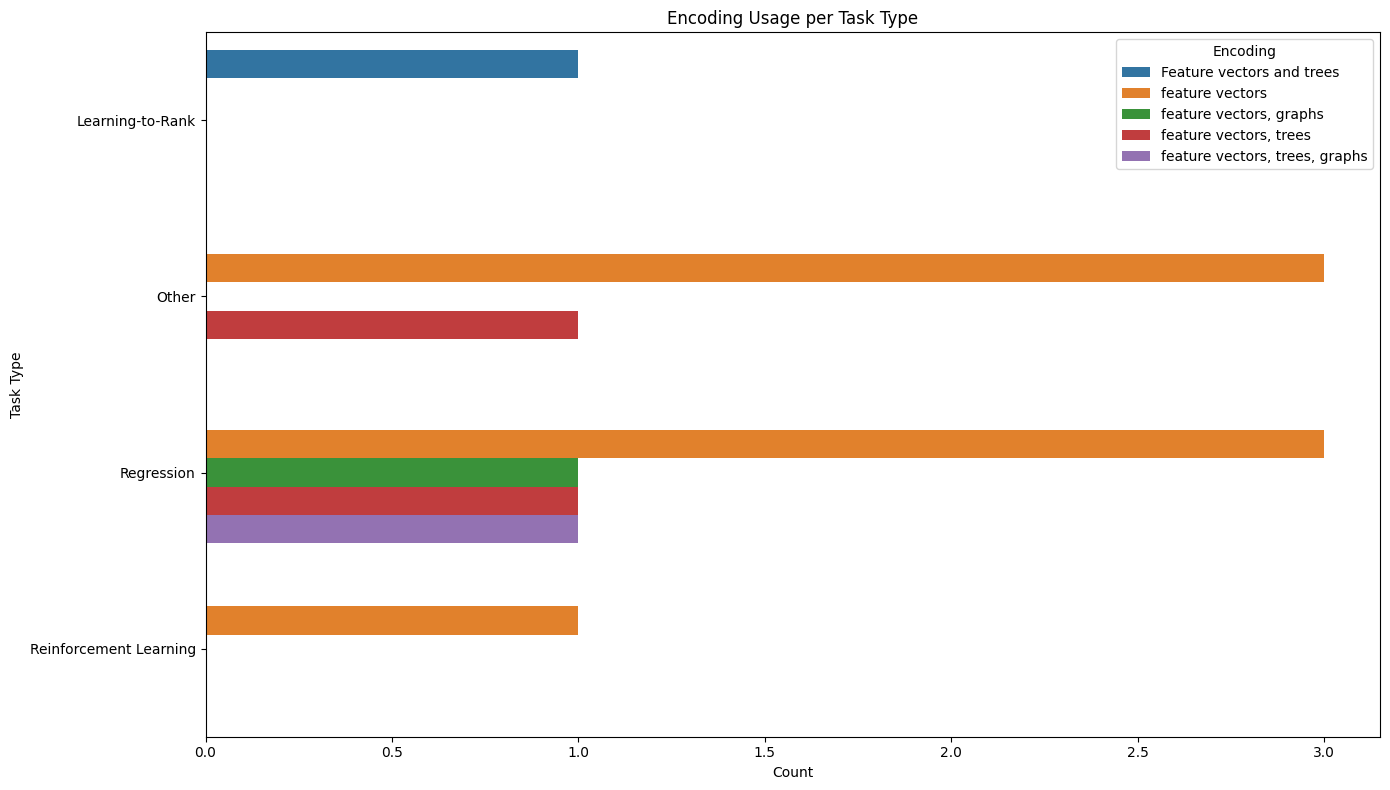

In [26]:
encoding_counts = allCategories.groupby(['Encoding', 'Task Type']).size().reset_index(name='Count')

plt.figure(figsize=(14, 8))
sns.barplot(data=encoding_counts, x='Count', y='Task Type', hue='Encoding')
plt.title("Encoding Usage per Task Type")
plt.tight_layout()
plt.show()

## Trends in Dataset Used

In [27]:
df = cited_df[['Published Year', 'Q10-ShortAnswer']].dropna()
df['Q10-ShortAnswer'] = df['Q10-ShortAnswer'].apply(
    lambda x: [item.strip().upper() for item in x.split(',')]
)
df = df.explode('Q10-ShortAnswer').rename(columns={'Q10-ShortAnswer': 'Benchmark'})

### Distribution of Benchmarks used Over all Papers

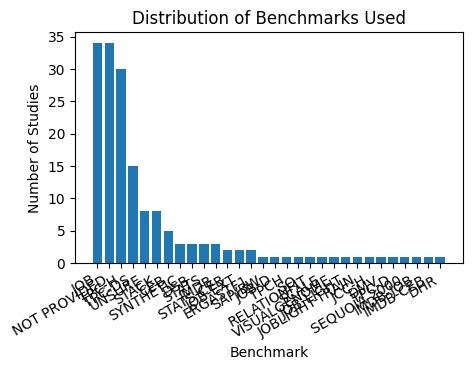

In [28]:
freq = df.loc[:,"Benchmark"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(5, 3))
plt.bar(freq.index, freq.values)
plt.xlabel("Benchmark")
plt.ylabel("Number of Studies")
plt.title("Distribution of Benchmarks Used")
plt.xticks(rotation=30, ha='right')  # Rotates the x-tick labels by 30 degrees
plt.show()

### Distribution of Benchmarks used Over Time

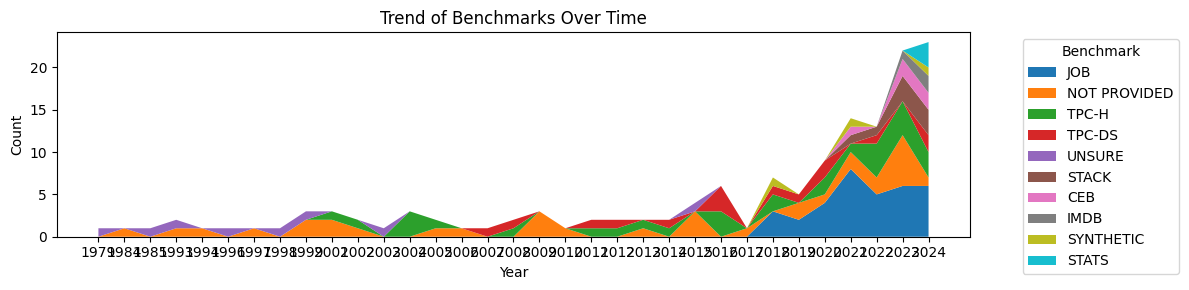

In [29]:
benchmark_trend = df.groupby(['Published Year', 'Benchmark']).size().reset_index(name='Count')
pivot_table = benchmark_trend.pivot(index='Published Year', columns='Benchmark', values='Count').fillna(0)


total_counts = pivot_table.sum(axis=0)
sorted_benchmarks = total_counts.sort_values(ascending=False).index
pivot_table = pivot_table[sorted_benchmarks]


years = pivot_table.index.values
stack_data = [pivot_table[benchmark].values for benchmark in pivot_table.columns]

top_n = 10
pivot_table = pivot_table[sorted_benchmarks[:top_n]]
stack_data = [pivot_table[col].values for col in pivot_table.columns]


cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(pivot_table.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(pivot_table.index.values, stack_data, labels=pivot_table.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trend of Benchmarks Over Time")
plt.legend(title="Benchmark", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()